### Objective: 
Analyze and predict personalized post-meal glucose response using CGM, nutrition, metabolic, activity, gut-health, and microbiome data.

### Methods:
Feature engineering, mixed-effects modeling, clustering, Random Forest regression, GroupKFold cross-validation, permutation importance, and matched-meal analysis.

### Step 1: Load Final Cleaned Datasets

In [1]:
import pandas as pd
import numpy as np

cg = pd.read_csv(
    r"C:\Users\karth\Downloads\DataMiners06_CGMacros_CleanedData.csv"
)

bio = pd.read_csv(
    r"C:\Users\karth\Downloads\DataMiners06_Bio_CleanedData.csv"
)

gut = pd.read_csv(
    r"C:\Users\karth\Downloads\DataMiners06_GutHealthTest_CleanedData.csv"
)

microbes = pd.read_csv(
    r"C:\Users\karth\Downloads\Microbes_long.csv"
)

In [2]:
print("CGMacros:", cg.shape)
print("Bio:", bio.shape)
print("Gut Health:", gut.shape)
print("Microbes:", microbes.shape)

CGMacros: (687580, 20)
Bio: (45, 24)
Gut Health: (45, 23)
Microbes: (89055, 3)


### Step 2: Validate Dataset Dimensions and Subject Alignment

In [3]:
print("CGMacros subjects:", cg["subject"].nunique())
print("Bio subjects:", bio["subject"].nunique())
print("Gut Health subjects:", gut["subject"].nunique())
print("Microbes subjects:", microbes["subject"].nunique())

subjects_cg = set(cg["subject"].unique())
subjects_bio = set(bio["subject"].unique())
subjects_gut = set(gut["subject"].unique())
subjects_microbes = set(microbes["subject"].unique())

common_subjects = (
    subjects_cg
    & subjects_bio
    & subjects_gut
    & subjects_microbes
)

print("\nCommon subjects across all 4 datasets:", len(common_subjects))
print(sorted(common_subjects))

CGMacros subjects: 45
Bio subjects: 45
Gut Health subjects: 45
Microbes subjects: 45

Common subjects across all 4 datasets: 45
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 41, 42, 43, 44, 45, 46, 47, 48, 49]


In [4]:
print("Only in CGMacros:", sorted(subjects_cg - subjects_bio))
print("Only in Bio:", sorted(subjects_bio - subjects_cg))
print("Only in Gut Health:", sorted(subjects_gut - subjects_bio))
print("Only in Microbes:", sorted(subjects_microbes - subjects_bio))

Only in CGMacros: []
Only in Bio: []
Only in Gut Health: []
Only in Microbes: []


### Step 3: Create Subject-Level CGM Summary Metrics

In [5]:
cgm_subject = (
    cg.groupby("subject")
      .agg(
          avg_glucose=("libre_gl", "mean"),
          glucose_sd=("libre_gl", "std"),
          min_glucose=("libre_gl", "min"),
          max_glucose=("libre_gl", "max")
      )
      .reset_index()
)

cgm_subject["glucose_cv_pct"] = (
    cgm_subject["glucose_sd"] /
    cgm_subject["avg_glucose"] * 100
)

cgm_subject.head()

,subject,avg_glucose,glucose_sd,min_glucose,max_glucose,glucose_cv_pct
0,1,88.517379,9.086953,54.0,127.0,10.265728
1,2,78.987430,22.409895,40.0,157.0,28.371470
2,3,107.573086,30.143157,45.0,261.0,28.021096
3,4,90.820349,16.223583,60.0,168.0,17.863378
4,5,111.505394,30.180750,40.0,237.0,27.066628


### Step 4: Calculate CGM Range-Based Metrics

In [6]:
range_metrics = (
    cg.groupby("subject")["libre_gl"]
      .agg(
          tir_pct=lambda x: ((x >= 70) & (x <= 180)).mean() * 100,
          titr_70_140_pct=lambda x: ((x >= 70) & (x <= 140)).mean() * 100,
          time_above_140_pct=lambda x: (x > 140).mean() * 100,
          tar_pct=lambda x: (x > 180).mean() * 100,
          tbr_pct=lambda x: (x < 70).mean() * 100
      )
      .reset_index()
)

cgm_subject = cgm_subject.merge(
    range_metrics,
    on="subject",
    how="left"
)

### Step 5: Calculate Microbial Richness by Subject

In [7]:
microbe_richness = (
    microbes.groupby("subject")["presence"]
    .sum(min_count=1)
    .reset_index(name="microbial_richness")
)

### Step 6: Integrate Bio, CGM, Gut Health, and Microbiome Data

In [8]:
subject_df = (
    bio
    .merge(cgm_subject, on="subject", how="left")
    .merge(gut, on="subject", how="left")
    .merge(microbe_richness, on="subject", how="left")
)

### Step 7: Classify Participants by Metabolic Status

In [9]:
def diabetes_group(a1c):
    if pd.isna(a1c):
        return "Unknown"
    elif a1c < 5.7:
        return "Normal"
    elif 5.7 <= a1c <= 6.4:
        return "Pre-diabetes"
    elif a1c > 6.4:
        return "Type 2 Diabetes"
    else:
        return "Unknown"

subject_df["diabetes_group"] = (
    subject_df["a1c_pdl_lab"].apply(diabetes_group)
)

#### Step 7.1 Validate Metabolic Group Counts

In [10]:
subject_df["diabetes_group"].value_counts()

diabetes_group
Pre-diabetes       16
Normal             15
Type 2 Diabetes    14
Name: count, dtype: int64

### Step 8: Create Additional Metabolic Risk Features
Reason: The triglyceride-to-HDL ratio was derived as an additional metabolic feature to compare lipid-related metabolic patterns across Normal, Pre-diabetes, and Type 2 Diabetes participants.

This feature will later be used together with BMI, fasting glucose, insulin, CGM variability, and hyperglycemic exposure for Prediabetes phenotype discovery.

In [11]:
# Create Triglyceride-to-HDL ratio
subject_df["tg_hdl_ratio"] = (
    subject_df["triglycerides"] /
    subject_df["hdl"]
)

# Review the new feature
subject_df[
    [
        "subject",
        "diabetes_group",
        "triglycerides",
        "hdl",
        "tg_hdl_ratio"
    ]
].head(10)

,subject,diabetes_group,triglycerides,hdl,tg_hdl_ratio
0,1,Normal,67,74,0.905405
1,2,Normal,61,91,0.670330
2,3,Type 2 Diabetes,154,74,2.081081
3,4,Normal,300,46,6.521739
4,5,Type 2 Diabetes,392,38,10.315789
5,6,Normal,75,72,1.041667
6,7,Pre-diabetes,92,43,2.139535
7,8,Pre-diabetes,145,60,2.416667
8,9,Pre-diabetes,312,40,7.800000
9,10,Pre-diabetes,101,55,1.836364


In [12]:
subject_df["tg_hdl_ratio"] = subject_df["tg_hdl_ratio"].round(2)

#### Step 8.1: Compare TG/HDL Ratio Across Metabolic Groups
TG/HDL ratio rises progressively from Normal to Pre-diabetes to Type 2 Diabetes, suggesting that lipid-related metabolic dysfunction accompanies worsening glycemic status. However, wide within-group variation indicates that participants with the same diagnosis can have very different metabolic profiles.

In [13]:
tg_hdl_summary = (
    subject_df
    .groupby("diabetes_group")["tg_hdl_ratio"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

tg_hdl_summary

,count,mean,median,min,max
diabetes_group,,,,,
Normal,15,1.89,1.57,0.67,6.52
Pre-diabetes,16,3.23,2.45,0.57,7.80
Type 2 Diabetes,14,7.20,3.76,1.36,47.92


### Step 9: Prepare Prediabetes Cohort for Metabolic Phenotype Discovery

In [14]:
features = [
    "bmi",
    "fasting_glu_pdl_lab",
    "insulin",
    "tg_hdl_ratio",
    "avg_glucose",
    "glucose_cv_pct",
    "titr_70_140_pct",
    "time_above_140_pct",
    "tar_pct"
]

prediabetes_df = (
    subject_df[
        subject_df["diabetes_group"] == "Pre-diabetes"
    ][["subject"] + features]
    .copy()
)

prediabetes_df

,subject,bmi,fasting_glu_pdl_lab,insulin,tg_hdl_ratio,avg_glucose,glucose_cv_pct,titr_70_140_pct,time_above_140_pct,tar_pct
6,7,27.08,108,15.9,2.14,54.279929,36.229678,17.471264,0.512821,0.000000
7,8,39.95,112,17.7,2.42,93.817073,20.230145,90.494580,2.845528,0.182927
8,9,37.01,122,25.7,7.80,106.378149,20.452953,91.510090,6.986778,1.259569
9,10,35.82,100,15.3,1.84,92.646673,24.304038,86.530486,3.534509,0.420922
10,11,29.17,109,11.6,6.86,110.853293,18.870527,90.476190,9.523810,1.188788
12,13,32.63,103,18.3,1.95,126.085795,18.663270,78.339646,21.401515,3.137626
15,16,45.94,104,26.0,1.64,84.779312,17.276173,88.041743,0.042971,0.000000
19,20,35.96,119,17.3,3.20,131.510209,21.470773,66.266913,33.733087,6.918819
21,22,20.69,107,3.2,0.57,98.504170,16.029701,97.339007,2.099291,0.073759
22,23,24.25,135,5.2,1.44,112.773309,26.343214,81.482854,16.768613,3.534137


#### Step 9:1 Check Missing Values Before Clustering

In [15]:
prediabetes_df.isna().sum()

subject                0
bmi                    0
fasting_glu_pdl_lab    0
insulin                0
tg_hdl_ratio           0
avg_glucose            0
glucose_cv_pct         0
titr_70_140_pct        0
time_above_140_pct     0
tar_pct                0
dtype: int64

### Step 10: Check Feature Relationships Before Clustering
Are some of our selected metabolic features measuring essentially the same thing?

In [16]:
# Features selected for phenotype analysis
features = [
    "bmi",
    "fasting_glu_pdl_lab",
    "insulin",
    "tg_hdl_ratio",
    "avg_glucose",
    "glucose_cv_pct",
    "titr_70_140_pct",
    "time_above_140_pct",
    "tar_pct"
]

correlation_matrix = (
    prediabetes_df[features]
    .corr()
    .round(2)
)

correlation_matrix

,bmi,fasting_glu_pdl_lab,insulin,tg_hdl_ratio,avg_glucose,glucose_cv_pct,titr_70_140_pct,time_above_140_pct,tar_pct
bmi,1.00,-0.37,0.48,0.08,-0.17,-0.19,0.18,-0.22,-0.19
fasting_glu_pdl_lab,-0.37,1.00,0.28,0.29,0.58,0.37,-0.10,0.64,0.75
insulin,0.48,0.28,1.00,0.56,0.10,0.30,-0.08,0.13,0.39
tg_hdl_ratio,0.08,0.29,0.56,1.00,0.24,0.10,0.13,0.13,0.23
avg_glucose,-0.17,0.58,0.10,0.24,1.00,-0.20,0.31,0.87,0.73
glucose_cv_pct,-0.19,0.37,0.30,0.10,-0.20,1.00,-0.80,0.19,0.39
titr_70_140_pct,0.18,-0.10,-0.08,0.13,0.31,-0.80,1.00,-0.18,-0.24
time_above_140_pct,-0.22,0.64,0.13,0.13,0.87,0.19,-0.18,1.00,0.87
tar_pct,-0.19,0.75,0.39,0.23,0.73,0.39,-0.24,0.87,1.00


#### Step 10.1: Identify Strongly Correlated Features

In [17]:
import numpy as np

corr = prediabetes_df[features].corr().abs()

upper = corr.where(
    np.triu(
        np.ones(corr.shape),
        k=1
    ).astype(bool)
)

strong_pairs = [
    (column, index, upper.loc[index, column])
    for column in upper.columns
    for index in upper.index
    if pd.notna(upper.loc[index, column])
    and upper.loc[index, column] >= 0.80
]

strong_pairs

[('time_above_140_pct', 'avg_glucose', 0.8697515665577952),
 ('tar_pct', 'time_above_140_pct', 0.8681124821767309)]

#### Step 10.2: Select Non-Redundant Features for Prediabetes Phenotype Discovery
Highly correlated CGM features were reviewed before clustering to reduce redundancy and prevent closely related variables from receiving excessive influence. Six complementary features were retained to represent body composition, baseline glucose regulation, insulin response, lipid-related metabolic status, average glucose burden, and glucose variability.

In [18]:
phenotype_features = [
    "bmi",
    "fasting_glu_pdl_lab",
    "insulin",
    "tg_hdl_ratio",
    "avg_glucose",
    "glucose_cv_pct"
]

### Step 11: Standardize Selected Metabolic Features Using Robust Scaling
Robust scaling was applied because the selected metabolic features are measured on different numerical scales and contain some extreme values. RobustScaler uses the median and interquartile range, reducing the influence of outliers while preserving meaningful metabolic differences between participants.

In [19]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Final non-redundant features selected for phenotype discovery
phenotype_features = [
    "bmi",
    "fasting_glu_pdl_lab",
    "insulin",
    "tg_hdl_ratio",
    "avg_glucose",
    "glucose_cv_pct"
]

# Extract selected features
X = prediabetes_df[phenotype_features].copy()

# Apply Robust Scaling
scaler = RobustScaler()

X_scaled_array = scaler.fit_transform(X)

# Convert back to DataFrame for easier interpretation
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=phenotype_features,
    index=prediabetes_df.index
)

X_scaled.head()

,bmi,fasting_glu_pdl_lab,insulin,tg_hdl_ratio,avg_glucose,glucose_cv_pct
6,-0.769648,-0.117647,-0.220690,-0.180233,-2.393391,2.950589
7,0.974255,0.070588,0.027586,-0.017442,-0.642174,-0.282816
8,0.575881,0.541176,1.131034,3.110465,-0.085807,-0.237788
9,0.414634,-0.494118,-0.303448,-0.354651,-0.694015,0.540492
10,-0.486450,-0.070588,-0.813793,2.563953,0.112410,-0.557586


In [20]:
X_scaled.describe().round(2)

,bmi,fasting_glu_pdl_lab,insulin,tg_hdl_ratio,avg_glucose,glucose_cv_pct
count,16.00,16.00,16.00,16.00,16.00,16.00
mean,0.09,0.27,0.05,0.45,-0.14,0.25
std,1.01,0.73,1.36,1.25,0.90,1.09
min,-1.64,-0.68,-1.97,-1.09,-2.39,-1.13
25%,-0.53,-0.31,-0.62,-0.32,-0.66,-0.43
50%,-0.00,0.00,0.00,-0.00,0.00,0.00
75%,0.47,0.69,0.38,0.68,0.34,0.57
max,2.21,1.76,3.99,3.11,1.11,2.95


### Step 12: Determine the Optimal Number of Prediabetes Phenotypes
How many distinct metabolic phenotypes are naturally present within the 16 Prediabetes participants?

Silhouette analysis was used to determine whether the Prediabetes cohort naturally separates into distinct metabolic phenotypes. Multiple cluster solutions were evaluated rather than predefining lower-risk and higher-risk groups in advance.

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

cluster_results = []

for k in range(2, 6):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    cluster_results.append({
        "number_of_clusters": k,
        "silhouette_score": score
    })

cluster_evaluation = pd.DataFrame(cluster_results)

cluster_evaluation

,number_of_clusters,silhouette_score
0,2,0.364231
1,3,0.236064
2,4,0.234648
3,5,0.235317


### Step 13: Identify Two Prediabetes Metabolic Phenotypes
The two-cluster solution produced the highest silhouette score among the tested cluster counts, indicating the clearest separation within the Prediabetes cohort. K-Means was therefore used to assign each participant to one of two exploratory metabolic phenotypes.

In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=50
)

prediabetes_df["cluster"] = kmeans.fit_predict(X_scaled)

prediabetes_df[
    [
        "subject",
        "cluster",
        "bmi",
        "fasting_glu_pdl_lab",
        "insulin",
        "tg_hdl_ratio",
        "avg_glucose",
        "glucose_cv_pct"
    ]
].sort_values("cluster")

,subject,cluster,bmi,fasting_glu_pdl_lab,insulin,tg_hdl_ratio,avg_glucose,glucose_cv_pct
6,7,0,27.08,108,15.9,2.14,54.279929,36.229678
7,8,0,39.95,112,17.7,2.42,93.817073,20.230145
9,10,0,35.82,100,15.3,1.84,92.646673,24.304038
10,11,0,29.17,109,11.6,6.86,110.853293,18.870527
12,13,0,32.63,103,18.3,1.95,126.085795,18.663270
15,16,0,45.94,104,26.0,1.64,84.779312,17.276173
19,20,0,35.96,119,17.3,3.20,131.510209,21.470773
21,22,0,20.69,107,3.2,0.57,98.504170,16.029701
22,23,0,24.25,135,5.2,1.44,112.773309,26.343214
23,26,0,31.17,104,17.8,4.64,97.549020,21.788375


#### Step 13.1: Check Cluster Sizes

In [23]:
prediabetes_df["cluster"].value_counts().sort_index()

cluster
0    14
1     2
Name: count, dtype: int64

### Step 14: Compare and Interpret Prediabetes Cluster Profiles

In [24]:
cluster_mean = (
    prediabetes_df
    .groupby("cluster")[
        [
            "bmi",
            "fasting_glu_pdl_lab",
            "insulin",
            "tg_hdl_ratio",
            "avg_glucose",
            "glucose_cv_pct",
            "titr_70_140_pct",
            "time_above_140_pct",
            "tar_pct"
        ]
    ]
    .mean()
    .round(2)
)

cluster_median = (
    prediabetes_df
    .groupby("cluster")[
        [
            "bmi",
            "fasting_glu_pdl_lab",
            "insulin",
            "tg_hdl_ratio",
            "avg_glucose",
            "glucose_cv_pct",
            "titr_70_140_pct",
            "time_above_140_pct",
            "tar_pct"
        ]
    ]
    .median()
    .round(2)
)

print("Cluster Mean:")
display(cluster_mean)

print("Cluster Median:")
display(cluster_median)

Cluster Mean:


,bmi,fasting_glu_pdl_lab,insulin,tg_hdl_ratio,avg_glucose,glucose_cv_pct,titr_70_140_pct,time_above_140_pct,tar_pct
cluster,,,,,,,,,
0,33.22,113.57,15.28,2.65,103.42,22.31,79.36,11.15,2.05
1,34.95,135.00,36.05,7.30,117.34,26.63,81.25,16.91,6.89


Cluster Median:


,bmi,fasting_glu_pdl_lab,insulin,tg_hdl_ratio,avg_glucose,glucose_cv_pct,titr_70_140_pct,time_above_140_pct,tar_pct
cluster,,,,,,,,,
0,31.90,108.5,16.60,2.28,104.38,21.63,85.19,7.21,0.80
1,34.95,135.0,36.05,7.30,117.34,26.63,81.25,16.91,6.89


#### Step 14.1: Identify the Features Driving Cluster Separation

This tells us whether the separation is mainly coming from:

*insulin

*TG/HDL

*fasting glucose

*CGM burden

*or some combination

#### Step 14.2: Validate the Cluster Solution With Hierarchical Clustering
If K-Means and hierarchical clustering independently identify a similar subgroup, the phenotype finding becomes much more credible.

If they produce very different groupings, then the Prediabetes data may not contain stable discrete phenotypes.

In [25]:
from sklearn.cluster import AgglomerativeClustering

hierarchical_model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

prediabetes_df["hierarchical_cluster"] = (
    hierarchical_model.fit_predict(X_scaled)
)

prediabetes_df[
    ["subject", "cluster", "hierarchical_cluster"]
].sort_values("subject")

,subject,cluster,hierarchical_cluster
6,7,0,0
7,8,0,0
8,9,1,0
9,10,0,0
10,11,0,0
12,13,0,0
15,16,0,0
19,20,0,0
21,22,0,0
22,23,0,0


##### Exploratory clustering identified a small subgroup of Prediabetes participants with distinctly elevated metabolic features. Additional validation was performed to determine whether this represented a stable metabolic phenotype or primarily reflected extreme participants.
##### Most Prediabetes participants overlap metabolically, but a small subset may already exhibit disproportionately adverse metabolic characteristics.    

### Step 15: Replace clustering with metabolic similarity analysis
Which Prediabetes participants are metabolically closer to Normal, and which are closer to Type 2 Diabetes?

In [26]:
similarity_features = [
    "bmi",
    "fasting_glu_pdl_lab",
    "insulin",
    "tg_hdl_ratio",
    "avg_glucose",
    "glucose_cv_pct"
]

In [27]:
from sklearn.preprocessing import RobustScaler
import pandas as pd
import numpy as np

X_all = subject_df[similarity_features].copy()

scaler_similarity = RobustScaler()
X_all_scaled = scaler_similarity.fit_transform(X_all)

scaled_subjects = pd.DataFrame(
    X_all_scaled,
    columns=similarity_features,
    index=subject_df.index
)

scaled_subjects["subject"] = subject_df["subject"].values
scaled_subjects["diabetes_group"] = subject_df["diabetes_group"].values

#### Step 15.1 Calculate Typical Normal and T2D Profiles

In [28]:
normal_profile = (
    scaled_subjects[
        scaled_subjects["diabetes_group"] == "Normal"
    ][similarity_features]
    .median()
)

t2d_profile = (
    scaled_subjects[
        scaled_subjects["diabetes_group"] == "Type 2 Diabetes"
    ][similarity_features]
    .median()
)

#### Step 15.2  Calculate Distance From Each Prediabetes Subject
Prediabetes was not a single uniform metabolic state. Rather than forming two stable clusters, participants appeared to lie along a continuum between Normal-like and Type-2-Diabetes-like metabolic profiles.

In [29]:
pred_similarity = scaled_subjects[
    scaled_subjects["diabetes_group"] == "Pre-diabetes"
].copy()

pred_similarity["distance_to_normal"] = pred_similarity[
    similarity_features
].apply(
    lambda row: np.linalg.norm(row.values - normal_profile.values),
    axis=1
)

pred_similarity["distance_to_t2d"] = pred_similarity[
    similarity_features
].apply(
    lambda row: np.linalg.norm(row.values - t2d_profile.values),
    axis=1
)

In [30]:
pred_similarity["closer_profile"] = np.where(
    pred_similarity["distance_to_normal"]
    < pred_similarity["distance_to_t2d"],
    "More Normal-like",
    "More T2D-like"
)

pred_similarity[
    [
        "subject",
        "distance_to_normal",
        "distance_to_t2d",
        "closer_profile"
    ]
].sort_values("distance_to_normal")

,subject,distance_to_normal,distance_to_t2d,closer_profile
21,22,1.162163,2.690156,More Normal-like
9,10,1.438756,1.903905,More Normal-like
22,23,1.509312,1.581125,More Normal-like
23,26,1.627733,1.720445,More Normal-like
39,44,1.672630,1.234757,More T2D-like
12,13,1.759868,1.713685,More T2D-like
36,41,1.794847,0.849656,More T2D-like
26,29,1.863685,1.381952,More T2D-like
7,8,1.941613,2.050953,More Normal-like
10,11,1.998600,1.827447,More T2D-like


### Step 16: Create a Normal-to-T2D Metabolic Similarity Score

In [31]:
pred_similarity["metabolic_similarity_score"] = (
    pred_similarity["distance_to_normal"]
    - pred_similarity["distance_to_t2d"]
) / (
    pred_similarity["distance_to_normal"]
    + pred_similarity["distance_to_t2d"]
)

similarity_results = pred_similarity[
    [
        "subject",
        "distance_to_normal",
        "distance_to_t2d",
        "metabolic_similarity_score",
        "closer_profile"
    ]
].sort_values("metabolic_similarity_score")

similarity_results

,subject,distance_to_normal,distance_to_t2d,metabolic_similarity_score,closer_profile
21,22,1.162163,2.690156,-0.396642,More Normal-like
9,10,1.438756,1.903905,-0.139155,More Normal-like
6,7,2.098374,2.664680,-0.118896,More Normal-like
23,26,1.627733,1.720445,-0.027691,More Normal-like
7,8,1.941613,2.050953,-0.027386,More Normal-like
15,16,2.996583,3.143166,-0.023874,More Normal-like
22,23,1.509312,1.581125,-0.023237,More Normal-like
38,43,3.006668,2.972357,0.005739,More T2D-like
12,13,1.759868,1.713685,0.013296,More T2D-like
10,11,1.998600,1.827447,0.044734,More T2D-like


### Step 17: Validate Metabolic Similarity Using Independent CGM Metrics
Do participants who appear more T2D-like also show worse CGM range metrics that were not used to create the score?

In [32]:
validation_df = (
    prediabetes_df[
        [
            "subject",
            "titr_70_140_pct",
            "time_above_140_pct",
            "tar_pct"
        ]
    ]
    .merge(
        similarity_results[
            ["subject", "metabolic_similarity_score"]
        ],
        on="subject",
        how="left"
    )
)

validation_df.sort_values(
    "metabolic_similarity_score"
)

,subject,titr_70_140_pct,time_above_140_pct,tar_pct,metabolic_similarity_score
8,22,97.339007,2.099291,0.073759,-0.396642
3,10,86.530486,3.534509,0.420922,-0.139155
0,7,17.471264,0.512821,0.000000,-0.118896
10,26,91.648284,4.889706,0.257353,-0.027691
1,8,90.494580,2.845528,0.182927,-0.027386
6,16,88.041743,0.042971,0.000000,-0.023874
9,23,81.482854,16.768613,3.534137,-0.023237
13,43,83.856749,1.783747,0.000000,0.005739
5,13,78.339646,21.401515,3.137626,0.013296
4,11,90.476190,9.523810,1.188788,0.044734


In [33]:
validation_df[
    [
        "metabolic_similarity_score",
        "titr_70_140_pct",
        "time_above_140_pct",
        "tar_pct"
    ]
].corr().round(3)

,metabolic_similarity_score,titr_70_140_pct,time_above_140_pct,tar_pct
metabolic_similarity_score,1.000,-0.126,0.724,0.615
titr_70_140_pct,-0.126,1.000,-0.181,-0.236
time_above_140_pct,0.724,-0.181,1.000,0.868
tar_pct,0.615,-0.236,0.868,1.000


##### Prediabetes appears to exist along a metabolic continuum rather than as one uniform state. Participants with more T2D-like metabolic profiles showed substantially greater real-world hyperglycemic exposure, with the similarity score correlating 0.724 with time above 140 mg/dL and 0.615 with time above 180 mg/dL.

### Step 18: Visualize the Normal-to-T2D Prediabetes Continuum

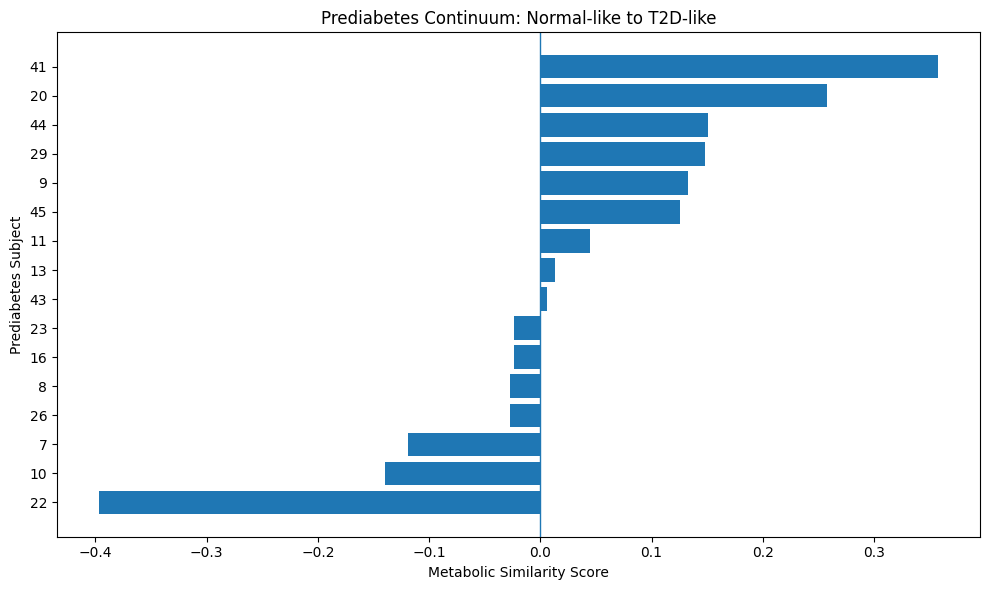

In [34]:
import matplotlib.pyplot as plt

plot_df = (
    similarity_results
    .sort_values("metabolic_similarity_score")
    .copy()
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["subject"].astype(str),
    plot_df["metabolic_similarity_score"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Metabolic Similarity Score")
plt.ylabel("Prediabetes Subject")
plt.title("Prediabetes Continuum: Normal-like to T2D-like")

plt.tight_layout()
plt.show()

### Step 19: Compare the Most Normal-Like and Most T2D-Like Prediabetes Profiles
What metabolic characteristics distinguish Prediabetes participants who are most Normal-like from those who are most T2D-like?

In [35]:
pred_profile_analysis = (
    subject_df[
        subject_df["diabetes_group"] == "Pre-diabetes"
    ][
        [
            "subject",
            "bmi",
            "fasting_glu_pdl_lab",
            "insulin",
            "tg_hdl_ratio",
            "avg_glucose",
            "glucose_cv_pct",
            "titr_70_140_pct",
            "time_above_140_pct",
            "tar_pct"
        ]
    ]
    .merge(
        similarity_results[
            [
                "subject",
                "metabolic_similarity_score",
                "closer_profile"
            ]
        ],
        on="subject",
        how="left"
    )
)

pred_profile_analysis = pred_profile_analysis.sort_values(
    "metabolic_similarity_score"
)

pred_profile_analysis

,subject,bmi,fasting_glu_pdl_lab,insulin,tg_hdl_ratio,avg_glucose,glucose_cv_pct,titr_70_140_pct,time_above_140_pct,tar_pct,metabolic_similarity_score,closer_profile
8,22,20.69,107,3.2,0.57,98.504170,16.029701,97.339007,2.099291,0.073759,-0.396642,More Normal-like
3,10,35.82,100,15.3,1.84,92.646673,24.304038,86.530486,3.534509,0.420922,-0.139155,More Normal-like
0,7,27.08,108,15.9,2.14,54.279929,36.229678,17.471264,0.512821,0.000000,-0.118896,More Normal-like
10,26,31.17,104,17.8,4.64,97.549020,21.788375,91.648284,4.889706,0.257353,-0.027691,More Normal-like
1,8,39.95,112,17.7,2.42,93.817073,20.230145,90.494580,2.845528,0.182927,-0.027386,More Normal-like
6,16,45.94,104,26.0,1.64,84.779312,17.276173,88.041743,0.042971,0.000000,-0.023874,More Normal-like
9,23,24.25,135,5.2,1.44,112.773309,26.343214,81.482854,16.768613,3.534137,-0.023237,More Normal-like
13,43,49.09,96,21.7,2.48,89.688223,22.298244,83.856749,1.783747,0.000000,0.005739,More T2D-like
5,13,32.63,103,18.3,1.95,126.085795,18.663270,78.339646,21.401515,3.137626,0.013296,More T2D-like
4,11,29.17,109,11.6,6.86,110.853293,18.870527,90.476190,9.523810,1.188788,0.044734,More T2D-like


#### Step 19.1 Identify the Strongest Ends of the Continuum

In [36]:
most_normal_like = (
    pred_profile_analysis
    .nsmallest(3, "metabolic_similarity_score")
)

most_t2d_like = (
    pred_profile_analysis
    .nlargest(3, "metabolic_similarity_score")
)

print("Most Normal-like Prediabetes participants:")
display(most_normal_like)

print("Most T2D-like Prediabetes participants:")
display(most_t2d_like)

Most Normal-like Prediabetes participants:


,subject,bmi,fasting_glu_pdl_lab,insulin,tg_hdl_ratio,avg_glucose,glucose_cv_pct,titr_70_140_pct,time_above_140_pct,tar_pct,metabolic_similarity_score,closer_profile
8,22,20.69,107,3.2,0.57,98.504170,16.029701,97.339007,2.099291,0.073759,-0.396642,More Normal-like
3,10,35.82,100,15.3,1.84,92.646673,24.304038,86.530486,3.534509,0.420922,-0.139155,More Normal-like
0,7,27.08,108,15.9,2.14,54.279929,36.229678,17.471264,0.512821,0.000000,-0.118896,More Normal-like


Most T2D-like Prediabetes participants:


,subject,bmi,fasting_glu_pdl_lab,insulin,tg_hdl_ratio,avg_glucose,glucose_cv_pct,titr_70_140_pct,time_above_140_pct,tar_pct,metabolic_similarity_score,closer_profile
12,41,27.86,138,10.6,1.92,133.386583,24.818409,68.693222,31.306778,10.593990,0.357417,More T2D-like
7,20,35.96,119,17.3,3.20,131.510209,21.470773,66.266913,33.733087,6.918819,0.258053,More T2D-like
14,44,35.92,119,13.5,2.69,111.774475,24.313107,80.928793,17.426901,1.272790,0.150607,More T2D-like


#### Step 19.2 Compare Metabolic Characteristics at Both Ends of the Prediabetes Continuum

In [37]:
most_normal_like = most_normal_like.copy()
most_t2d_like = most_t2d_like.copy()

most_normal_like["continuum_group"] = "Most Normal-like"
most_t2d_like["continuum_group"] = "Most T2D-like"

extreme_profiles = pd.concat(
    [most_normal_like, most_t2d_like],
    ignore_index=True
)

In [38]:
profile_comparison = (
    extreme_profiles
    .groupby("continuum_group")[
        [
            "bmi",
            "fasting_glu_pdl_lab",
            "insulin",
            "tg_hdl_ratio",
            "avg_glucose",
            "glucose_cv_pct",
            "titr_70_140_pct",
            "time_above_140_pct",
            "tar_pct"
        ]
    ]
    .mean()
    .round(2)
)

profile_comparison

,bmi,fasting_glu_pdl_lab,insulin,tg_hdl_ratio,avg_glucose,glucose_cv_pct,titr_70_140_pct,time_above_140_pct,tar_pct
continuum_group,,,,,,,,,
Most Normal-like,27.86,105.00,11.47,1.52,81.81,25.52,67.11,2.05,0.16
Most T2D-like,33.25,125.33,13.80,2.60,125.56,23.53,71.96,27.49,6.26


#### Step 19.3 Calculate the Differences

In [39]:
profile_difference = (
    profile_comparison.loc["Most T2D-like"]
    - profile_comparison.loc["Most Normal-like"]
)

profile_difference = (
    profile_difference
    .sort_values(key=abs, ascending=False)
    .round(2)
)

profile_difference

avg_glucose            43.75
time_above_140_pct     25.44
fasting_glu_pdl_lab    20.33
tar_pct                 6.10
bmi                     5.39
titr_70_140_pct         4.85
insulin                 2.33
glucose_cv_pct         -1.99
tg_hdl_ratio            1.08
dtype: float64

##### Prediabetes was not metabolically uniform. Participants at the T2D-like end of the continuum had markedly higher average glucose, fasting glucose, and hyperglycemic exposure than those at the Normal-like end, despite belonging to the same HbA1c-defined Prediabetes category.

### Step 20: Build Meal-Level Glucose Response Dataset
How does glucose change during the 2 hours after each meal, and why do similar meals produce different responses across participants?

#### Step 20.1: Keep only rows where a meal is recorded

In [40]:
meal_rows = cg[
    cg["meal_type"].notna()
].copy()

print("Number of meal records:", len(meal_rows))

meal_rows[
    [
        "subject",
        "timestamp",
        "meal_type",
        "calories",
        "carbs",
        "protein",
        "fat",
        "fiber",
        "amount_consumed"
    ]
].head(10)

Number of meal records: 1706


,subject,timestamp,meal_type,calories,carbs,protein,fat,fiber,amount_consumed
233,1,5/1/2020 14:23,lunch,1170.0,85.0,88.0,54.2,12.0,100.0
618,1,5/1/2020 20:48,dinner,80.0,18.0,0.0,0.0,0.0,100.0
825,1,5/2/2020 0:15,snack,110.0,24.0,0.0,2.0,0.0,100.0
1308,1,5/2/2020 8:18,breakfast,448.0,66.0,22.0,10.5,0.0,100.0
1530,1,5/2/2020 12:00,lunch,840.0,89.0,17.0,42.0,3.0,100.0
1807,1,5/2/2020 16:37,snack,38.0,9.0,0.0,0.0,0.0,100.0
2002,1,5/2/2020 19:52,dinner,330.0,32.0,4.0,22.0,4.0,100.0
2253,1,5/3/2020 0:03,snack,160.0,29.0,2.0,4.0,0.0,100.0
2797,1,5/3/2020 9:07,breakfast,608.0,66.0,66.0,10.5,0.0,100.0
3141,1,5/3/2020 14:51,lunch,615.0,26.0,67.0,30.0,3.0,100.0


#### Step 20.2 Check meal counts by type

In [41]:
meal_rows["meal_type"].value_counts()

meal_type
dinner       492
breakfast    436
lunch        435
snack        343
Name: count, dtype: int64

#### Step 20.3 Check for duplicate meal events

In [42]:
meal_duplicates = meal_rows.duplicated(
    subset=["subject", "timestamp"],
    keep=False
)

print("Duplicate subject-meal timestamps:", meal_duplicates.sum())

meal_rows.loc[
    meal_duplicates,
    ["subject", "timestamp", "meal_type", "carbs", "calories"]
].head(20)

Duplicate subject-meal timestamps: 0


,subject,timestamp,meal_type,carbs,calories


### Step 21: Prepare Time-Series Data for Post-Meal Glucose Analysis

The CGMacros dataset was sorted by participant and timestamp to ensure that glucose observations could be correctly aligned with each meal and its subsequent 2-hour response window.

In [43]:
# Ensure timestamp is datetime
cg["timestamp"] = pd.to_datetime(
    cg["timestamp"],
    errors="coerce"
)

# Sort chronologically within each subject
cg = (
    cg.sort_values(["subject", "timestamp"])
      .reset_index(drop=True)
)

print("Invalid timestamps:", cg["timestamp"].isna().sum())

Invalid timestamps: 0


#### Step 21.1 Standardize Meal Event Timestamps

In [44]:
# Convert meal event timestamps to datetime
meal_rows["timestamp"] = pd.to_datetime(
    meal_rows["timestamp"],
    errors="coerce"
)

print("Invalid meal timestamps:", meal_rows["timestamp"].isna().sum())
print("Meal timestamp dtype:", meal_rows["timestamp"].dtype)

Invalid meal timestamps: 0
Meal timestamp dtype: datetime64[ns]


### Step 22: Calculate 2-Hour Post-Meal Glucose Response Features

In [45]:
import numpy as np

def nearest_glucose(subject_data, target_time, tolerance_minutes=5):
    
    window = subject_data[
        subject_data["timestamp"].between(
            target_time - pd.Timedelta(minutes=tolerance_minutes),
            target_time + pd.Timedelta(minutes=tolerance_minutes)
        )
    ].dropna(subset=["libre_gl"])

    if window.empty:
        return np.nan

    closest_idx = (
        window["timestamp"] - target_time
    ).abs().idxmin()

    return window.loc[closest_idx, "libre_gl"]

In [46]:
meal_results = []

for _, meal in meal_rows.iterrows():

    subject_id = meal["subject"]
    meal_time = meal["timestamp"]

    subject_data = cg[
        cg["subject"] == subject_id
    ]

    postmeal = subject_data[
        subject_data["timestamp"].between(
            meal_time,
            meal_time + pd.Timedelta(minutes=120)
        )
    ].dropna(subset=["libre_gl"])

    if postmeal.empty:
        continue

    baseline = nearest_glucose(
        subject_data,
        meal_time,
        tolerance_minutes=5
    )

    glucose_30 = nearest_glucose(
        subject_data,
        meal_time + pd.Timedelta(minutes=30)
    )

    glucose_60 = nearest_glucose(
        subject_data,
        meal_time + pd.Timedelta(minutes=60)
    )

    glucose_90 = nearest_glucose(
        subject_data,
        meal_time + pd.Timedelta(minutes=90)
    )

    glucose_120 = nearest_glucose(
        subject_data,
        meal_time + pd.Timedelta(minutes=120)
    )

    peak_idx = postmeal["libre_gl"].idxmax()
    peak_glucose = postmeal.loc[peak_idx, "libre_gl"]
    peak_time = postmeal.loc[peak_idx, "timestamp"]

    peak_rise = (
        peak_glucose - baseline
        if pd.notna(baseline)
        else np.nan
    )

    time_to_peak_min = (
        peak_time - meal_time
    ).total_seconds() / 60

    meal_results.append({
        "subject": subject_id,
        "meal_time": meal_time,
        "meal_type": meal["meal_type"],

        "calories": meal["calories"],
        "carbs": meal["carbs"],
        "protein": meal["protein"],
        "fat": meal["fat"],
        "fiber": meal["fiber"],
        "amount_consumed": meal["amount_consumed"],

        "baseline_glucose": baseline,
        "glucose_30": glucose_30,
        "glucose_60": glucose_60,
        "glucose_90": glucose_90,
        "glucose_120": glucose_120,

        "peak_glucose": peak_glucose,
        "peak_rise": peak_rise,
        "time_to_peak_min": time_to_peak_min
    })

meal_response_df = pd.DataFrame(meal_results)

In [47]:
print("Meal-response dataset shape:", meal_response_df.shape)

meal_response_df.head()

Meal-response dataset shape: (1706, 17)


,subject,meal_time,meal_type,calories,carbs,protein,fat,fiber,amount_consumed,baseline_glucose,glucose_30,glucose_60,glucose_90,glucose_120,peak_glucose,peak_rise,time_to_peak_min
0,1,2020-05-01 14:23:00,lunch,1170.0,85.0,88.0,54.2,12.0,100.0,69.8,74.87,88.93,89.73,79.13,93.0,23.2,97.0
1,1,2020-05-01 20:48:00,dinner,80.0,18.0,0.0,0.0,0.0,100.0,84.8,113.20,96.40,94.40,93.20,114.0,29.2,42.0
2,1,2020-05-02 00:15:00,snack,110.0,24.0,0.0,2.0,0.0,100.0,81.0,107.00,96.00,95.00,83.00,113.0,32.0,45.0
3,1,2020-05-02 08:18:00,breakfast,448.0,66.0,22.0,10.5,0.0,100.0,88.4,114.80,96.80,100.40,70.60,118.0,29.6,42.0
4,1,2020-05-02 12:00:00,lunch,840.0,89.0,17.0,42.0,3.0,100.0,82.0,103.00,76.00,92.00,93.00,103.0,21.0,30.0


#### Step 22.1 Check Missing Response Measurements

In [48]:
meal_response_df[
    [
        "baseline_glucose",
        "glucose_30",
        "glucose_60",
        "glucose_90",
        "glucose_120",
        "peak_glucose",
        "peak_rise"
    ]
].isna().sum()

baseline_glucose    1
glucose_30          3
glucose_60          5
glucose_90          3
glucose_120         7
peak_glucose        0
peak_rise           1
dtype: int64

### Step 23: Create Complete Meal-Response Records for Advanced Analysis

Only meals with complete baseline and 30-, 60-, 90-, and 120-minute glucose measurements were retained for analyses requiring a full 2-hour response curve. Missing values were not imputed because only a small number of meals were affected.

In [49]:
required_response_cols = [
    "baseline_glucose",
    "glucose_30",
    "glucose_60",
    "glucose_90",
    "glucose_120"
]

meal_complete_df = (
    meal_response_df
    .dropna(subset=required_response_cols)
    .copy()
)

print("Original meals:", len(meal_response_df))
print("Complete 2-hour response meals:", len(meal_complete_df))
print(
    "Meals excluded:",
    len(meal_response_df) - len(meal_complete_df)
)

Original meals: 1706
Complete 2-hour response meals: 1698
Meals excluded: 8


### Step 24: Calculate 2-Hour Post-Meal Glucose Recovery
Does glucose return toward baseline within two hours after eating?

In [50]:
meal_complete_df["glucose_change_120"] = (
    meal_complete_df["glucose_120"]
    - meal_complete_df["baseline_glucose"]
)

meal_complete_df["recovery_from_peak"] = (
    meal_complete_df["peak_glucose"]
    - meal_complete_df["glucose_120"]
)

meal_complete_df[
    [
        "subject",
        "meal_type",
        "baseline_glucose",
        "peak_glucose",
        "glucose_120",
        "peak_rise",
        "glucose_change_120",
        "recovery_from_peak"
    ]
].head()

,subject,meal_type,baseline_glucose,peak_glucose,glucose_120,peak_rise,glucose_change_120,recovery_from_peak
0,1,lunch,69.8,93.0,79.13,23.2,9.33,13.87
1,1,dinner,84.8,114.0,93.20,29.2,8.40,20.80
2,1,snack,81.0,113.0,83.00,32.0,2.00,30.00
3,1,breakfast,88.4,118.0,70.60,29.6,-17.80,47.40
4,1,lunch,82.0,103.0,93.00,21.0,11.00,10.00


### Step 25: Calculate 2-Hour Incremental Area Under the Curve (iAUC)
How much total glucose exposure occurred above the pre-meal baseline during the 2-hour period?

In [51]:
import numpy as np

# Time points in minutes
time_points = np.array([0, 30, 60, 90, 120])

def calculate_iauc(row):
    glucose_values = np.array([
        row["baseline_glucose"],
        row["glucose_30"],
        row["glucose_60"],
        row["glucose_90"],
        row["glucose_120"]
    ], dtype=float)

    # Calculate glucose values above the meal baseline
    incremental = glucose_values - row["baseline_glucose"]

    # Keep only area above baseline
    incremental = np.maximum(incremental, 0)

    # Calculate iAUC using trapezoidal integration
    return np.trapz(
        incremental,
        time_points
    )

# Apply the function to every meal
meal_complete_df["iauc_2hr"] = meal_complete_df.apply(
    calculate_iauc,
    axis=1
)

# Review results
meal_complete_df[
    [
        "subject",
        "meal_type",
        "baseline_glucose",
        "peak_rise",
        "glucose_change_120",
        "iauc_2hr"
    ]
].head(10)

,subject,meal_type,baseline_glucose,peak_rise,glucose_change_120,iauc_2hr
0,1,lunch,69.80,23.20,9.33,1463.85
1,1,dinner,84.80,29.20,8.40,1614.00
2,1,snack,81.00,32.00,2.00,1680.00
3,1,breakfast,88.40,29.60,-17.80,1404.00
4,1,lunch,82.00,21.00,11.00,1095.00
5,1,snack,95.13,8.87,-9.20,280.20
6,1,dinner,94.27,4.73,-0.40,30.00
7,1,snack,90.40,23.60,6.00,1200.00
8,1,breakfast,86.27,18.73,-2.87,709.80
9,1,lunch,79.00,10.00,8.20,741.00


### Step 26: Add Participant Metabolic Status and Bio Features to Meal Responses

In [52]:
meal_complete_df = meal_complete_df.merge(
    subject_df[
        [
            "subject",
            "diabetes_group",
            "bmi",
            "fasting_glu_pdl_lab",
            "insulin",
            "tg_hdl_ratio"
        ]
    ],
    on="subject",
    how="left"
)

meal_complete_df[
    [
        "subject",
        "diabetes_group",
        "meal_type",
        "peak_rise",
        "glucose_change_120",
        "iauc_2hr"
    ]
].head(10)

,subject,diabetes_group,meal_type,peak_rise,glucose_change_120,iauc_2hr
0,1,Normal,lunch,23.20,9.33,1463.85
1,1,Normal,dinner,29.20,8.40,1614.00
2,1,Normal,snack,32.00,2.00,1680.00
3,1,Normal,breakfast,29.60,-17.80,1404.00
4,1,Normal,lunch,21.00,11.00,1095.00
5,1,Normal,snack,8.87,-9.20,280.20
6,1,Normal,dinner,4.73,-0.40,30.00
7,1,Normal,snack,23.60,6.00,1200.00
8,1,Normal,breakfast,18.73,-2.87,709.80
9,1,Normal,lunch,10.00,8.20,741.00


In [53]:
print(meal_complete_df["diabetes_group"].isna().sum())
print(meal_complete_df["diabetes_group"].value_counts())

0
diabetes_group
Normal             630
Pre-diabetes       613
Type 2 Diabetes    455
Name: count, dtype: int64


### Step 27: Compare Post-Meal Glucose Response Across Metabolic Groups
Do Normal, Pre-diabetes, and Type 2 Diabetes participants differ in how high they spike, how long glucose stays elevated, and how well they recover after meals?

In [54]:
meal_group_summary = (
    meal_complete_df
    .groupby("diabetes_group")[
        [
            "peak_rise",
            "iauc_2hr",
            "glucose_change_120",
            "recovery_from_peak",
            "time_to_peak_min"
        ]
    ]
    .agg(["mean", "median"])
    .round(2)
)

meal_group_summary

peak_rise        iauc_2hr          glucose_change_120         \
                     mean median     mean   median               mean median   
diabetes_group                                                                 
Normal              28.19  23.30  1627.44  1015.27               9.19    6.0   
Pre-diabetes        41.68  37.00  2633.74  2085.00              19.56   17.0   
Type 2 Diabetes     58.95  51.53  3772.57  3106.95              32.10   28.2   

                recovery_from_peak        time_to_peak_min         
                              mean median             mean median  
diabetes_group                                                     
Normal                       19.00  14.10            56.96   49.0  
Pre-diabetes                 22.11  17.13            62.31   57.0  
Type 2 Diabetes              26.85  14.67            71.19   72.0

#### Step 27.1 Count Meals Per Group

In [55]:
meal_complete_df.groupby(
    "diabetes_group"
).size()

diabetes_group
Normal             630
Pre-diabetes       613
Type 2 Diabetes    455
dtype: int64

#### Step 27.2 Compare Peak Rise Only

In [56]:
meal_complete_df.groupby(
    "diabetes_group"
)["peak_rise"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
diabetes_group,,,,,,
Normal,630,28.19,23.30,25.28,0.0,175.00
Pre-diabetes,613,41.68,37.00,30.28,0.0,177.87
Type 2 Diabetes,455,58.95,51.53,46.41,0.0,215.00


#### Step 27.3 Compare iAUC

In [57]:
meal_complete_df.groupby(
    "diabetes_group"
)["iauc_2hr"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
diabetes_group,,,,,,
Normal,630,1627.44,1015.27,1942.34,0.0,14371.65
Pre-diabetes,613,2633.74,2085.00,2354.50,0.0,13000.20
Type 2 Diabetes,455,3772.57,3106.95,3431.74,0.0,15297.00


#### Step 27.4 Compare 2-Hour Recovery

In [58]:
meal_complete_df.groupby(
    "diabetes_group"
)[
    ["glucose_change_120", "recovery_from_peak"]
].agg(
    ["mean", "median", "std"]
).round(2)

glucose_change_120               recovery_from_peak         \
                              mean median    std               mean median   
diabetes_group                                                               
Normal                        9.19    6.0  25.32              19.00  14.10   
Pre-diabetes                 19.56   17.0  31.58              22.11  17.13   
Type 2 Diabetes              32.10   28.2  52.96              26.85  14.67   

                        
                   std  
diabetes_group          
Normal           19.16  
Pre-diabetes     21.01  
Type 2 Diabetes  32.34

### Step 28: Test Metabolic-Group Differences Using Mixed-Effects Models

In [59]:
import statsmodels.formula.api as smf

#### Step 28.1  Peak Rise

In [60]:
peak_model = smf.mixedlm(
    "peak_rise ~ C(diabetes_group)",
    data=meal_complete_df,
    groups=meal_complete_df["subject"]
)

peak_result = peak_model.fit()

print(peak_result.summary())

                     Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        peak_rise 
No. Observations:          1698           Method:                    REML      
No. Groups:                45             Scale:                     978.8779  
Min. group size:           15             Log-Likelihood:            -8294.8658
Max. group size:           64             Converged:                 Yes       
Mean group size:           37.7                                                
-------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z   P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                             29.240    3.796 7.703 0.000 21.800 36.680
C(diabetes_group)[T.Pre-diabetes]     12.348    5.301 2.329 0.020  1.958 22.738
C(diabetes_group)[T.Type 2 Diabetes]  30.366    5.505 5.517 0

#### Step 28.2  iAUC

In [61]:
iauc_model = smf.mixedlm(
    "iauc_2hr ~ C(diabetes_group)",
    data=meal_complete_df,
    groups=meal_complete_df["subject"]
)

iauc_result = iauc_model.fit()

print(iauc_result.summary())

                         Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          iauc_2hr    
No. Observations:            1698             Method:                      REML        
No. Groups:                  45               Scale:                       5383751.7659
Min. group size:             15               Log-Likelihood:              -15598.8663 
Max. group size:             64               Converged:                   Yes         
Mean group size:             37.7                                                      
---------------------------------------------------------------------------------------
                                        Coef.    Std.Err.   z   P>|z|  [0.025   0.975] 
---------------------------------------------------------------------------------------
Intercept                               1697.280  316.949 5.355 0.000 1076.071 2318.489
C(diabetes_group)[T.Pre-diabetes]        906.137  442.346

#### Step 28.3  120-Minute Glucose Change

In [62]:
recovery_model = smf.mixedlm(
    "glucose_change_120 ~ C(diabetes_group)",
    data=meal_complete_df,
    groups=meal_complete_df["subject"]
)

recovery_result = recovery_model.fit()

print(recovery_result.summary())

                    Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     glucose_change_120
No. Observations:       1698        Method:                 REML              
No. Groups:             45          Scale:                  1270.0882         
Min. group size:        15          Log-Likelihood:         -8498.2390        
Max. group size:        64          Converged:              Yes               
Mean group size:        37.7                                                  
------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                             9.510    2.832 3.358 0.001  3.959 15.062
C(diabetes_group)[T.Pre-diabetes]    10.349    3.971 2.606 0.009  2.567 18.131
C(diabetes_group)[T.Type 2 Diabetes] 22.745    4.149 5.481 0.000 14.612 3

#### Step 28.4 Time to Peak

In [63]:
time_peak_model = smf.mixedlm(
    "time_to_peak_min ~ C(diabetes_group)",
    data=meal_complete_df,
    groups=meal_complete_df["subject"]
)

time_peak_result = time_peak_model.fit()

print(time_peak_result.summary())

                     Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       time_to_peak_min
No. Observations:       1698          Method:                   REML            
No. Groups:             45            Scale:                    1189.7099       
Min. group size:        15            Log-Likelihood:           -8451.8038      
Max. group size:        64            Converged:                Yes             
Mean group size:        37.7                                                    
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             56.912    3.416 16.663 0.000 50.218 63.606
C(diabetes_group)[T.Pre-diabetes]      6.396    4.778  1.339 0.181 -2.969 15.761
C(diabetes_group)[T.Type 2 Diabetes]  13.746    4.

##### Post-meal glucose regulation progressively deteriorated from Normal to Prediabetes to Type 2 Diabetes. Prediabetes already showed significantly larger glucose excursions, greater 2-hour glucose burden, and poorer recovery than Normal participants, while Type 2 Diabetes showed the largest and most prolonged responses.

### Step 29: Does Metabolic Status Still Matter After Accounting for the Meal?Meal factors

1.Meal factors

*carbs
*protein
*fat
*fiber
*meal type

versus

2.Person factors

*metabolic group
*BMI
*fasting glucose
*insulin
*TG/HDL
*baseline glucose



#### Step 29.1 Validate Meal Composition Features Before Adjusted Analysis

In [64]:
meal_features = [
    "carbs",
    "protein",
    "fat",
    "fiber",
    "meal_type"
]

meal_complete_df[meal_features].isna().sum()

carbs        0
protein      0
fat          0
fiber        1
meal_type    0
dtype: int64

#### Step 29.1A Remove Incomplete Meal Composition Records for Modeling

In [65]:
adjusted_model_df = meal_complete_df.dropna(
    subset=[
        "peak_rise",
        "iauc_2hr",
        "glucose_change_120",
        "carbs",
        "protein",
        "fat",
        "fiber",
        "meal_type",
        "diabetes_group",
        "subject"
    ]
).copy()

print("Meals before modeling:", len(meal_complete_df))
print("Meals used for adjusted models:", len(adjusted_model_df))
print("Meals excluded:", len(meal_complete_df) - len(adjusted_model_df))

Meals before modeling: 1698
Meals used for adjusted models: 1697
Meals excluded: 1


#### Step 29.2 Adjusted Peak-Rise Model

In [66]:
adjusted_peak_model = smf.mixedlm(
    """
    peak_rise ~
    carbs +
    protein +
    fat +
    fiber +
    C(meal_type) +
    C(diabetes_group)
    """,
    data=adjusted_model_df,
    groups=adjusted_model_df["subject"]
)

adjusted_peak_result = adjusted_peak_model.fit()

print(adjusted_peak_result.summary())

                       Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          peak_rise 
No. Observations:          1697             Method:                      REML      
No. Groups:                45               Scale:                       821.4007  
Min. group size:           15               Log-Likelihood:              -8148.0936
Max. group size:           64               Converged:                   Yes       
Mean group size:           37.7                                                    
-----------------------------------------------------------------------------------
                                      Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------------------------
Intercept                             43.050    4.164  10.339 0.000  34.889  51.211
C(meal_type)[T.dinner]               -23.663    1.968 -12.026 0.000 -27.520 -19.807
C(meal_type)[T.

#### Step 29.3: Adjusted iAUC Model

In [67]:
adjusted_iauc_model = smf.mixedlm(
    """
    iauc_2hr ~
    carbs +
    protein +
    fat +
    fiber +
    C(meal_type) +
    C(diabetes_group)
    """,
    data=adjusted_model_df,
    groups=adjusted_model_df["subject"]
)

adjusted_iauc_result = adjusted_iauc_model.fit()

print(adjusted_iauc_result.summary())

                          Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           iauc_2hr    
No. Observations:             1697              Method:                       REML        
No. Groups:                   45                Scale:                        4689816.8844
Min. group size:              15                Log-Likelihood:               -15448.8078 
Max. group size:              64                Converged:                    Yes         
Mean group size:              37.7                                                        
------------------------------------------------------------------------------------------
                                        Coef.    Std.Err.   z    P>|z|   [0.025    0.975] 
------------------------------------------------------------------------------------------
Intercept                               2472.153  343.686  7.193 0.000  1798.542  3145.765
C(meal_type)[T.dinner]    

#### Step 29.4 Adjusted 120-Minute Recovery Model

In [68]:
adjusted_recovery_model = smf.mixedlm(
    """
    glucose_change_120 ~
    carbs +
    protein +
    fat +
    fiber +
    C(meal_type) +
    C(diabetes_group)
    """,
    data=adjusted_model_df,
    groups=adjusted_model_df["subject"]
)

adjusted_recovery_result = adjusted_recovery_model.fit()

print(adjusted_recovery_result.summary())

                      Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      glucose_change_120
No. Observations:        1697         Method:                  REML              
No. Groups:              45           Scale:                   1202.0933         
Min. group size:         15           Log-Likelihood:          -8449.9124        
Max. group size:         64           Converged:               Yes               
Mean group size:         37.7                                                    
---------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                             10.258    3.617  2.836 0.005   3.168 17.348
C(meal_type)[T.dinner]                -6.970    2.374 -2.936 0.003 -11.624 -2.317
C(meal_type)[T.lunch]                 

##### Meal composition matters, but it does not fully explain glucose response. Even after accounting for what was eaten, Prediabetes and Type 2 Diabetes participants showed significantly larger and more sustained post-meal glucose responses than Normal participants.

### Step 30: Compare Meal-Only, Person-Only, and Combined Predictive Models

In [69]:
model_df = adjusted_model_df[
    [
        "subject",
        "peak_rise",
        "iauc_2hr",

        # Meal features
        "carbs",
        "protein",
        "fat",
        "fiber",
        "meal_type",

        # Person features
        "bmi",
        "fasting_glu_pdl_lab",
        "insulin",
        "tg_hdl_ratio",
        "diabetes_group",

        # Baseline glucose before meal
        "baseline_glucose"
    ]
].copy()

print(model_df.shape)
print(model_df.isna().sum())

(1697, 14)
subject                0
peak_rise              0
iauc_2hr               0
carbs                  0
protein                0
fat                    0
fiber                  0
meal_type              0
bmi                    0
fasting_glu_pdl_lab    0
insulin                0
tg_hdl_ratio           0
diabetes_group         0
baseline_glucose       0
dtype: int64


### Step 31: Compare Meal-Only, Person-Only, and Combined Predictive Models
What predicts post-meal glucose response better: the meal, the person, or both together?

*Used GroupKFold by subject so meals from the same participant never appear in both training and testing.

#### Step 31.1 Import modeling tools

In [70]:
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

#### Step 31.2 Define feature sets

In [71]:
meal_features = [
    "carbs",
    "protein",
    "fat",
    "fiber",
    "meal_type"
]

person_features = [
    "bmi",
    "fasting_glu_pdl_lab",
    "insulin",
    "tg_hdl_ratio",
    "diabetes_group",
    "baseline_glucose"
]

combined_features = meal_features + person_features

#### Step 31.3 Create evaluation function

In [72]:
def evaluate_model(feature_list, target):

    X = model_df[feature_list].copy()
    y = model_df[target].copy()
    groups = model_df["subject"]

    categorical_cols = X.select_dtypes(include="object").columns.tolist()
    numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
        ]
    )

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv = GroupKFold(n_splits=5)

    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }

    scores = cross_validate(
        pipeline,
        X,
        y,
        groups=groups,
        cv=cv,
        scoring=scoring
    )

    return {
        "MAE": -scores["test_mae"].mean(),
        "RMSE": -scores["test_rmse"].mean(),
        "R2": scores["test_r2"].mean()
    }

#### Step 31.4 Predict Peak Rise

In [73]:
peak_results = pd.DataFrame({
    "Meal Only": evaluate_model(meal_features, "peak_rise"),
    "Person Only": evaluate_model(person_features, "peak_rise"),
    "Meal + Person": evaluate_model(combined_features, "peak_rise")
}).T.round(3)

peak_results

,MAE,RMSE,R2
Meal Only,25.002,32.514,0.159
Person Only,26.526,35.659,-0.017
Meal + Person,21.715,28.657,0.339


#### Step 31.5 Predict iAUC

In [74]:
iauc_results = pd.DataFrame({
    "Meal Only": evaluate_model(meal_features, "iauc_2hr"),
    "Person Only": evaluate_model(person_features, "iauc_2hr"),
    "Meal + Person": evaluate_model(combined_features, "iauc_2hr")
}).T.round(3)

iauc_results

,MAE,RMSE,R2
Meal Only,1880.164,2480.278,0.129
Person Only,1962.615,2701.491,-0.065
Meal + Person,1652.921,2259.305,0.263


### Step 32: Add Post-Meal Activity
Does what a person does after eating improve our ability to explain the glucose response?

#### Step 32:1 Add Post-Meal Activity to the Glucose Response Model

In [75]:
activity_results = []

for _, meal in meal_complete_df.iterrows():

    subject_id = meal["subject"]
    meal_time = meal["meal_time"]

    activity_window = cg[
        (cg["subject"] == subject_id) &
        (cg["timestamp"] >= meal_time) &
        (cg["timestamp"] <= meal_time + pd.Timedelta(minutes=120))
    ]

    activity_results.append({
        "subject": subject_id,
        "meal_time": meal_time,

        "postmeal_avg_mets": activity_window["mets"].mean(),
        "postmeal_avg_hr": activity_window["hr"].mean(),
        "postmeal_steps": activity_window["steps"].sum(min_count=1),
        "postmeal_activity_calories": activity_window[
            "calories_activity"
        ].sum(min_count=1)
    })

activity_df = pd.DataFrame(activity_results)

activity_df.head()

,subject,meal_time,postmeal_avg_mets,postmeal_avg_hr,postmeal_steps,postmeal_activity_calories
0,1,2020-05-01 14:23:00,25.842975,84.504132,NaN,327.8341
1,1,2020-05-01 20:48:00,11.859504,64.793388,NaN,150.4448
2,1,2020-05-02 00:15:00,21.123967,82.851240,NaN,267.9710
3,1,2020-05-02 08:18:00,30.826446,90.578512,NaN,391.0526
4,1,2020-05-02 12:00:00,14.925620,78.300000,NaN,189.3407


#### Step 32.2 Merge Activity Into the Meal Dataset

In [76]:
meal_complete_df = meal_complete_df.merge(
    activity_df,
    on=["subject", "meal_time"],
    how="left"
)

meal_complete_df[
    [
        "subject",
        "meal_time",
        "postmeal_avg_mets",
        "postmeal_avg_hr",
        "postmeal_steps",
        "postmeal_activity_calories"
    ]
].head()

,subject,meal_time,postmeal_avg_mets,postmeal_avg_hr,postmeal_steps,postmeal_activity_calories
0,1,2020-05-01 14:23:00,25.842975,84.504132,NaN,327.8341
1,1,2020-05-01 20:48:00,11.859504,64.793388,NaN,150.4448
2,1,2020-05-02 00:15:00,21.123967,82.851240,NaN,267.9710
3,1,2020-05-02 08:18:00,30.826446,90.578512,NaN,391.0526
4,1,2020-05-02 12:00:00,14.925620,78.300000,NaN,189.3407


#### Step 32.3 Check Activity Missingness

In [77]:
activity_features = [
    "postmeal_avg_mets",
    "postmeal_avg_hr",
    "postmeal_steps",
    "postmeal_activity_calories"
]

meal_complete_df[
    activity_features
].isna().sum()

postmeal_avg_mets              385
postmeal_avg_hr                 54
postmeal_steps                1683
postmeal_activity_calories      20
dtype: int64

#### Step 32.4 Examine Complementary Activity Data Availability

In [78]:
activity_availability = (
    meal_complete_df
    .groupby("subject")
    .agg(
        total_meals=("meal_time", "count"),
        meals_with_mets=(
            "postmeal_avg_mets",
            lambda x: x.notna().sum()
        ),
        meals_with_steps=(
            "postmeal_steps",
            lambda x: x.notna().sum()
        ),
        meals_with_hr=(
            "postmeal_avg_hr",
            lambda x: x.notna().sum()
        ),
        meals_with_activity_calories=(
            "postmeal_activity_calories",
            lambda x: x.notna().sum()
        )
    )
)

activity_availability

,total_meals,meals_with_mets,meals_with_steps,meals_with_hr,meals_with_activity_calories
subject,,,,,
1,43,43,0,43,43
2,37,37,0,34,37
3,35,35,0,35,35
4,60,60,0,60,60
5,46,46,0,45,46
6,38,38,0,38,38
7,15,15,15,15,0
8,30,30,0,30,30
9,40,40,0,40,40


In [79]:
activity_availability[
    (activity_availability["meals_with_mets"] == 0) &
    (activity_availability["meals_with_steps"] > 0)
]

,total_meals,meals_with_mets,meals_with_steps,meals_with_hr,meals_with_activity_calories
subject,,,,,


In [80]:
activity_availability[
    (activity_availability["meals_with_steps"] == 0) &
    (activity_availability["meals_with_mets"] > 0)
]

,total_meals,meals_with_mets,meals_with_steps,meals_with_hr,meals_with_activity_calories
subject,,,,,
1,43,43,0,43,43
2,37,37,0,34,37
3,35,35,0,35,35
4,60,60,0,60,60
5,46,46,0,45,46
6,38,38,0,38,38
8,30,30,0,30,30
9,40,40,0,40,40
10,45,45,0,45,45


#### Step 32.5 Identify the Activity Recording Pattern

In [81]:
print(
    "Meals with METs:",
    meal_complete_df["postmeal_avg_mets"].notna().sum()
)

print(
    "Meals with Steps:",
    meal_complete_df["postmeal_steps"].notna().sum()
)

print(
    "Meals with either METs or Steps:",
    (
        meal_complete_df["postmeal_avg_mets"].notna() |
        meal_complete_df["postmeal_steps"].notna()
    ).sum()
)

print(
    "Meals with both:",
    (
        meal_complete_df["postmeal_avg_mets"].notna() &
        meal_complete_df["postmeal_steps"].notna()
    ).sum()
)

Meals with METs: 1313
Meals with Steps: 15
Meals with either METs or Steps: 1313
Meals with both: 15


### Step 33: Select Reliable Post-Meal Activity Features
Activity Feature Selection: Step data were available for only 15 meal events and did not provide additional coverage beyond METs, as all meals with Steps also contained METs. Therefore, Steps were excluded from the primary activity model. Heart rate and activity calories were selected as the primary post-meal activity measures because they had substantially greater coverage. METs were retained for a secondary sensitivity analysis.

In [82]:
activity_model_df = meal_complete_df.dropna(
    subset=[
        "peak_rise",
        "iauc_2hr",
        "carbs",
        "protein",
        "fat",
        "fiber",
        "meal_type",
        "bmi",
        "fasting_glu_pdl_lab",
        "insulin",
        "tg_hdl_ratio",
        "diabetes_group",
        "baseline_glucose",
        "postmeal_avg_hr",
        "postmeal_activity_calories"
    ]
).copy()

print("Total meal-response records:", len(meal_complete_df))
print("Meals available for activity model:", len(activity_model_df))
print("Meals excluded:", len(meal_complete_df) - len(activity_model_df))
print("Subjects retained:", activity_model_df["subject"].nunique())

Total meal-response records: 1698
Meals available for activity model: 1628
Meals excluded: 70
Subjects retained: 44


#### Step 33.1 Identify Subject Excluded From Activity Model

In [83]:
all_subjects = set(meal_complete_df["subject"].unique())
retained_subjects = set(activity_model_df["subject"].unique())

excluded_subjects = sorted(all_subjects - retained_subjects)

print("Excluded subject(s):", excluded_subjects)

Excluded subject(s): [7]


In [84]:
meal_complete_df[
    meal_complete_df["subject"].isin(excluded_subjects)
][
    [
        "subject",
        "meal_time",
        "postmeal_avg_hr",
        "postmeal_activity_calories",
        "postmeal_avg_mets",
        "postmeal_steps"
    ]
].head(50)

,subject,meal_time,postmeal_avg_hr,postmeal_activity_calories,postmeal_avg_mets,postmeal_steps
259,7,2023-11-03 12:38:00,71.422018,NaN,18.743119,790.0
260,7,2023-11-03 19:26:00,61.673913,NaN,12.500000,158.0
261,7,2023-11-04 19:16:00,63.783784,NaN,16.837838,232.0
262,7,2023-11-05 08:38:00,90.121951,NaN,32.963415,1165.0
263,7,2023-11-05 12:23:00,72.090909,NaN,16.909091,115.0
264,7,2023-11-05 19:18:00,62.857143,NaN,13.725275,300.0
265,7,2023-11-06 07:51:00,85.096774,NaN,34.612903,1170.0
266,7,2023-11-06 08:31:00,75.714286,NaN,19.785714,384.0
267,7,2023-11-07 08:32:00,75.782609,NaN,17.065217,113.0
268,7,2023-11-07 12:18:00,65.229508,NaN,14.049180,194.0


#### Step 33.2 Build Activity Model Using HR + METs

In [85]:
activity_model_df = meal_complete_df.dropna(
    subset=[
        "peak_rise",
        "iauc_2hr",
        "carbs",
        "protein",
        "fat",
        "fiber",
        "meal_type",
        "bmi",
        "fasting_glu_pdl_lab",
        "insulin",
        "tg_hdl_ratio",
        "diabetes_group",
        "baseline_glucose",
        "postmeal_avg_hr",
        "postmeal_avg_mets"
    ]
).copy()

print("Meals used:", len(activity_model_df))
print("Subjects retained:", activity_model_df["subject"].nunique())

Meals used: 1279
Subjects retained: 34


In [86]:
sorted(
    set(meal_complete_df["subject"].unique())
    - set(activity_model_df["subject"].unique())
)

[11, 26, 27, 31, 32, 33, 34, 35, 38, 42, 46]

#### Step 33.3 Compare Activity Model Coverage

In [87]:
# HR-only activity model
hr_model_df = meal_complete_df.dropna(
    subset=[
        "peak_rise",
        "iauc_2hr",
        "carbs",
        "protein",
        "fat",
        "fiber",
        "meal_type",
        "bmi",
        "fasting_glu_pdl_lab",
        "insulin",
        "tg_hdl_ratio",
        "diabetes_group",
        "baseline_glucose",
        "postmeal_avg_hr"
    ]
).copy()

# HR + METs activity model
hr_mets_model_df = meal_complete_df.dropna(
    subset=[
        "peak_rise",
        "iauc_2hr",
        "carbs",
        "protein",
        "fat",
        "fiber",
        "meal_type",
        "bmi",
        "fasting_glu_pdl_lab",
        "insulin",
        "tg_hdl_ratio",
        "diabetes_group",
        "baseline_glucose",
        "postmeal_avg_hr",
        "postmeal_avg_mets"
    ]
).copy()

print("HR-only model")
print("Meals:", len(hr_model_df))
print("Subjects:", hr_model_df["subject"].nunique())

print("\nHR + METs model")
print("Meals:", len(hr_mets_model_df))
print("Subjects:", hr_mets_model_df["subject"].nunique())

print("\nSubjects missing from HR-only:")
print(sorted(
    set(meal_complete_df["subject"]) -
    set(hr_model_df["subject"])
))

print("\nSubjects missing from HR + METs:")
print(sorted(
    set(meal_complete_df["subject"]) -
    set(hr_mets_model_df["subject"])
))

HR-only model
Meals: 1643
Subjects: 45

HR + METs model
Meals: 1279
Subjects: 34

Subjects missing from HR-only:
[]

Subjects missing from HR + METs:
[11, 26, 27, 31, 32, 33, 34, 35, 38, 42, 46]


##### Post-meal average heart rate was used as a high-coverage activity-related physiological feature. Although heart rate is not a direct activity measure, it can capture changes associated with post-meal movement and exertion. METs were retained as a secondary direct activity-intensity measure where available. Before concluding, we can check for Intensity and METs. 

#### Step 33.3A Calculate Post-Meal Intensity

In [88]:
intensity_results = []

for _, meal in meal_complete_df.iterrows():

    subject_id = meal["subject"]
    meal_time = meal["meal_time"]

    activity_window = cg[
        (cg["subject"] == subject_id) &
        (cg["timestamp"] >= meal_time) &
        (cg["timestamp"] <= meal_time + pd.Timedelta(minutes=120))
    ]

    intensity_results.append({
        "subject": subject_id,
        "meal_time": meal_time,
        "postmeal_avg_intensity":
            activity_window["intensity"].mean()
    })

intensity_df = pd.DataFrame(intensity_results)

meal_complete_df = meal_complete_df.merge(
    intensity_df,
    on=["subject", "meal_time"],
    how="left"
)

In [89]:
print(
    "Meals with METs:",
    meal_complete_df["postmeal_avg_mets"].notna().sum()
)

print(
    "Meals with Intensity:",
    meal_complete_df["postmeal_avg_intensity"].notna().sum()
)

print(
    "Meals with either METs or Intensity:",
    (
        meal_complete_df["postmeal_avg_mets"].notna() |
        meal_complete_df["postmeal_avg_intensity"].notna()
    ).sum()
)

print(
    "Meals with both:",
    (
        meal_complete_df["postmeal_avg_mets"].notna() &
        meal_complete_df["postmeal_avg_intensity"].notna()
    ).sum()
)

Meals with METs: 1313
Meals with Intensity: 380
Meals with either METs or Intensity: 1693
Meals with both: 0


#### Step 33.4 Check Intensity Availability by Subject

In [90]:
intensity_availability = (
    meal_complete_df
    .groupby("subject")
    .agg(
        total_meals=("meal_time", "count"),

        meals_with_mets=(
            "postmeal_avg_mets",
            lambda x: x.notna().sum()
        ),

        meals_with_intensity=(
            "postmeal_avg_intensity",
            lambda x: x.notna().sum()
        )
    )
)

intensity_availability

,total_meals,meals_with_mets,meals_with_intensity
subject,,,
1,43,43,0
2,37,37,0
3,35,35,0
4,60,60,0
5,46,46,0
6,38,38,0
7,15,15,0
8,30,30,0
9,40,40,0


#### Step 33.5 Create a Unified Post-Meal Activity Intensity Score

In [91]:
from sklearn.preprocessing import StandardScaler
import numpy as np

meal_complete_df["activity_intensity_score"] = np.nan

# -----------------------------
# Standardize METs
# -----------------------------
mets_mask = meal_complete_df["postmeal_avg_mets"].notna()

mets_scaler = StandardScaler()

meal_complete_df.loc[
    mets_mask,
    "activity_intensity_score"
] = mets_scaler.fit_transform(
    meal_complete_df.loc[
        mets_mask,
        ["postmeal_avg_mets"]
    ]
).ravel()


# -----------------------------
# Standardize Intensity
# -----------------------------
intensity_mask = (
    meal_complete_df["postmeal_avg_intensity"].notna()
)

intensity_scaler = StandardScaler()

meal_complete_df.loc[
    intensity_mask,
    "activity_intensity_score"
] = intensity_scaler.fit_transform(
    meal_complete_df.loc[
        intensity_mask,
        ["postmeal_avg_intensity"]
    ]
).ravel()

In [92]:
print(
    "Meals with unified activity score:",
    meal_complete_df[
        "activity_intensity_score"
    ].notna().sum()
)

print(
    "Meals missing unified activity score:",
    meal_complete_df[
        "activity_intensity_score"
    ].isna().sum()
)

print(
    "Subjects represented:",
    meal_complete_df[
        meal_complete_df["activity_intensity_score"].notna()
    ]["subject"].nunique()
)

Meals with unified activity score: 1693
Meals missing unified activity score: 5
Subjects represented: 45


#### Step 33.6 Record Which Activity Measure Was Used

In [93]:
meal_complete_df["activity_measure_source"] = np.select(
    [
        meal_complete_df["postmeal_avg_mets"].notna(),
        meal_complete_df["postmeal_avg_intensity"].notna()
    ],
    [
        "METs",
        "Intensity"
    ],
    default="Missing"
)

meal_complete_df[
    "activity_measure_source"
].value_counts()

activity_measure_source
METs         1313
Intensity     380
Missing         5
Name: count, dtype: int64

### Step 34: Test Whether Post-Meal Activity Improves Glucose Prediction

In [94]:
activity_model_df = meal_complete_df.dropna(
    subset=[
        "peak_rise",
        "iauc_2hr",
        "carbs",
        "protein",
        "fat",
        "fiber",
        "meal_type",
        "bmi",
        "fasting_glu_pdl_lab",
        "insulin",
        "tg_hdl_ratio",
        "diabetes_group",
        "baseline_glucose",
        "activity_intensity_score"
    ]
).copy()

print("Meals used:", len(activity_model_df))
print("Subjects retained:", activity_model_df["subject"].nunique())

Meals used: 1692
Subjects retained: 45


#### Step 34.1 Define Model 4 Features

In [95]:
activity_features = [
    "activity_intensity_score"
]

combined_activity_features = (
    combined_features + activity_features
)

#### Step 34.1A Recreate the Model Evaluation Function

In [96]:
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

def evaluate_model_df(data, feature_list, target):

    X = data[feature_list].copy()
    y = data[target].copy()
    groups = data["subject"]

    categorical_cols = (
        X.select_dtypes(include="object")
        .columns
        .tolist()
    )

    numeric_cols = (
        X.select_dtypes(exclude="object")
        .columns
        .tolist()
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                numeric_cols
            ),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_cols
            )
        ]
    )

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv = GroupKFold(n_splits=5)

    scores = cross_validate(
        pipeline,
        X,
        y,
        groups=groups,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        }
    )

    return {
        "MAE": -scores["test_mae"].mean(),
        "RMSE": -scores["test_rmse"].mean(),
        "R2": scores["test_r2"].mean()
    }

In [97]:
meal_features = [
    "carbs",
    "protein",
    "fat",
    "fiber",
    "meal_type"
]

person_features = [
    "bmi",
    "fasting_glu_pdl_lab",
    "insulin",
    "tg_hdl_ratio",
    "diabetes_group",
    "baseline_glucose"
]

combined_features = meal_features + person_features

activity_features = [
    "activity_intensity_score"
]

combined_activity_features = (
    combined_features + activity_features
)

#### Step 34.2 Compare Model 3 vs Model 4 for Peak Rise

In [98]:
peak_activity_results = pd.DataFrame({

    "Meal + Person":
        evaluate_model_df(
            activity_model_df,
            combined_features,
            "peak_rise"
        ),

    "Meal + Person + Activity":
        evaluate_model_df(
            activity_model_df,
            combined_activity_features,
            "peak_rise"
        )

}).T.round(3)

peak_activity_results

,MAE,RMSE,R2
Meal + Person,21.182,28.086,0.368
Meal + Person + Activity,21.098,27.930,0.376


#### Step 34.3 Test Whether Activity Improves iAUC Prediction

In [99]:
iauc_activity_results = pd.DataFrame({

    "Meal + Person":
        evaluate_model_df(
            activity_model_df,
            combined_features,
            "iauc_2hr"
        ),

    "Meal + Person + Activity":
        evaluate_model_df(
            activity_model_df,
            combined_activity_features,
            "iauc_2hr"
        )

}).T.round(3)

iauc_activity_results

,MAE,RMSE,R2
Meal + Person,1611.617,2213.704,0.293
Meal + Person + Activity,1602.008,2186.451,0.312


##### Adding post-meal activity intensity gave a modest but consistent improvement in predicting both peak glucose rise and total 2-hour glucose burden.

##### The strongest predictions came from combining multiple layers of information. Meal composition provides useful signal, person-level metabolic context improves it substantially, and activity adds a smaller additional gain.

### Step 35: Prepare Gut Health and Microbiome Features
Does gut-health information add predictive value beyond Meal + Person + Activity?

#### Step 35.1: Validate Gut Health and Microbiome Features

In [100]:
gut_features_candidate = [
    "gut_microbiome_health",
    "metabolic_fitness",
    "active_microbial_diversity",
    "butyrate_production_pathways",
    "lps_biosynthesis_pathways",
    "inflammatory_activity",
    "microbial_richness"
]

# Check that the columns exist
for col in gut_features_candidate:
    print(
        col,
        "Exists:" if col in subject_df.columns else "MISSING"
    )

gut_microbiome_health Exists:
metabolic_fitness Exists:
active_microbial_diversity Exists:
butyrate_production_pathways Exists:
lps_biosynthesis_pathways Exists:
inflammatory_activity Exists:
microbial_richness Exists:


In [101]:
subject_df[
    gut_features_candidate
].isna().sum()

gut_microbiome_health           3
metabolic_fitness               3
active_microbial_diversity      3
butyrate_production_pathways    3
lps_biosynthesis_pathways       3
inflammatory_activity           3
microbial_richness              0
dtype: int64

#### Step 35.2 Check Gut-Feature Redundancy

In [102]:
gut_corr = (
    subject_df[gut_features_candidate]
    .corr()
    .round(2)
)

gut_corr

,gut_microbiome_health,metabolic_fitness,active_microbial_diversity,butyrate_production_pathways,lps_biosynthesis_pathways,inflammatory_activity,microbial_richness
gut_microbiome_health,1.00,0.60,0.63,0.53,0.44,0.61,-0.33
metabolic_fitness,0.60,1.00,0.48,0.61,-0.05,0.45,-0.00
active_microbial_diversity,0.63,0.48,1.00,0.40,0.29,0.41,-0.22
butyrate_production_pathways,0.53,0.61,0.40,1.00,-0.05,0.60,-0.17
lps_biosynthesis_pathways,0.44,-0.05,0.29,-0.05,1.00,0.02,-0.48
inflammatory_activity,0.61,0.45,0.41,0.60,0.02,1.00,-0.29
microbial_richness,-0.33,-0.00,-0.22,-0.17,-0.48,-0.29,1.00


In [103]:
import numpy as np
import pandas as pd

corr = subject_df[gut_features_candidate].corr().abs()

upper = corr.where(
    np.triu(
        np.ones(corr.shape),
        k=1
    ).astype(bool)
)

gut_strong_pairs = [
    (column, index, round(upper.loc[index, column], 2))
    for column in upper.columns
    for index in upper.index
    if pd.notna(upper.loc[index, column])
    and upper.loc[index, column] >= 0.80
]

gut_strong_pairs

[]

#### Step 35.3 Identify Participants With Incomplete Gut Health Features

In [104]:
gut_features = [
    "gut_microbiome_health",
    "metabolic_fitness",
    "active_microbial_diversity",
    "butyrate_production_pathways",
    "lps_biosynthesis_pathways",
    "inflammatory_activity",
    "microbial_richness"
]

missing_gut_subjects = subject_df.loc[
    subject_df[gut_features].isna().any(axis=1),
    ["subject"] + gut_features
]

missing_gut_subjects

,subject,gut_microbiome_health,metabolic_fitness,active_microbial_diversity,butyrate_production_pathways,lps_biosynthesis_pathways,inflammatory_activity,microbial_richness
23,26,NaN,NaN,NaN,NaN,NaN,NaN,182
25,28,NaN,NaN,NaN,NaN,NaN,NaN,168
43,48,NaN,NaN,NaN,NaN,NaN,NaN,0


In [105]:
print(
    "Subjects with incomplete gut features:",
    missing_gut_subjects["subject"].tolist()
)

Subjects with incomplete gut features: [26, 28, 48]


#### Step 35.4 Merge Gut Features Into the Meal-Level Dataset

In [106]:
meal_gut_df = activity_model_df.merge(
    subject_df[
        ["subject"] + gut_features
    ],
    on="subject",
    how="left"
)

print("Meals before gut filtering:", len(meal_gut_df))
print("Subjects before gut filtering:", meal_gut_df["subject"].nunique())

meal_gut_df[gut_features].isna().sum()

Meals before gut filtering: 1692
Subjects before gut filtering: 45


gut_microbiome_health           106
metabolic_fitness               106
active_microbial_diversity      106
butyrate_production_pathways    106
lps_biosynthesis_pathways       106
inflammatory_activity           106
microbial_richness                0
dtype: int64

#### Step 35.5 Create the Complete Gut-Model Dataset

In [107]:
gut_model_df = meal_gut_df.dropna(
    subset=gut_features
).copy()

print("Meals available for gut model:", len(gut_model_df))
print("Subjects retained:", gut_model_df["subject"].nunique())

excluded_gut_subjects = sorted(
    set(meal_gut_df["subject"].unique())
    - set(gut_model_df["subject"].unique())
)

print("Subjects excluded because gut data are unavailable:",
      excluded_gut_subjects)

Meals available for gut model: 1586
Subjects retained: 42
Subjects excluded because gut data are unavailable: [26, 28, 48]


### Step 36: Build Model 5 — Add Gut Health + Microbiome

#### Step 36.1 Define the final gut-enhanced feature set

In [108]:
gut_model_features = (
    combined_activity_features
    + gut_features
)

print("Number of Model 5 features:", len(gut_model_features))
print(gut_model_features)

Number of Model 5 features: 19
['carbs', 'protein', 'fat', 'fiber', 'meal_type', 'bmi', 'fasting_glu_pdl_lab', 'insulin', 'tg_hdl_ratio', 'diabetes_group', 'baseline_glucose', 'activity_intensity_score', 'gut_microbiome_health', 'metabolic_fitness', 'active_microbial_diversity', 'butyrate_production_pathways', 'lps_biosynthesis_pathways', 'inflammatory_activity', 'microbial_richness']


#### Step 36.2 Compare Model 4 vs Model 5 for Peak Rise

In [109]:
peak_gut_results = pd.DataFrame({

    "Meal + Person + Activity":
        evaluate_model_df(
            gut_model_df,
            combined_activity_features,
            "peak_rise"
        ),

    "Meal + Person + Activity + Gut/Microbiome":
        evaluate_model_df(
            gut_model_df,
            gut_model_features,
            "peak_rise"
        )

}).T.round(3)

peak_gut_results

,MAE,RMSE,R2
Meal + Person + Activity,21.571,29.005,0.365
Meal + Person + Activity + Gut/Microbiome,22.436,29.936,0.319


#### Step 36.3 Compare Model 4 vs Model 5 for iAUC

In [110]:
iauc_gut_results = pd.DataFrame({

    "Meal + Person + Activity":
        evaluate_model_df(
            gut_model_df,
            combined_activity_features,
            "iauc_2hr"
        ),

    "Meal + Person + Activity + Gut/Microbiome":
        evaluate_model_df(
            gut_model_df,
            gut_model_features,
            "iauc_2hr"
        )

}).T.round(3)

iauc_gut_results

,MAE,RMSE,R2
Meal + Person + Activity,1622.979,2245.816,0.324
Meal + Person + Activity + Gut/Microbiome,1681.021,2307.535,0.286


##### In this exploratory 42-subject sample, gut-health and microbiome summary features did not improve prediction of 2-hour glucose burden after meal, metabolic, and activity information were already included.

#### Step 36.4 Compare Model 4 vs Model 5 for Peak Rise

In [111]:
peak_gut_results = pd.DataFrame({

    "Meal + Person + Activity":
        evaluate_model_df(
            gut_model_df,
            combined_activity_features,
            "peak_rise"
        ),

    "Meal + Person + Activity + Gut/Microbiome":
        evaluate_model_df(
            gut_model_df,
            gut_model_features,
            "peak_rise"
        )

}).T.round(3)

peak_gut_results

,MAE,RMSE,R2
Meal + Person + Activity,21.571,29.005,0.365
Meal + Person + Activity + Gut/Microbiome,22.436,29.936,0.319


##### Gut-health and microbiome summary features did not improve prediction of either peak glucose rise or 2-hour glucose burden beyond meal composition, individual metabolic characteristics, and post-meal activity.

##### This does not mean the gut microbiome is unimportant. It only means that, in this small exploratory sample and with the summary features available, it did not add enough new predictive signal.

### Step 37: Compare Final Predictive Model Performance

For peak rise and iAUC, we have:

*Meal Only

*Person Only

*Meal + Person

*Meal + Person + Activity

*Meal + Person + Activity + Gut/Microbiome

##### Meal + Person performed much better than either alone. Activity added a small additional gain. Gut/microbiome summary features did not improve performance further.

#### Step 37.1 Final Peak Rise Comparison

In [112]:
final_peak_comparison = pd.DataFrame({
    "Meal Only": {
        "MAE": 25.002,
        "RMSE": 32.514,
        "R2": 0.159
    },

    "Person Only": {
        "MAE": 26.526,
        "RMSE": 35.659,
        "R2": -0.017
    },

    "Meal + Person": {
        "MAE": 21.715,
        "RMSE": 28.657,
        "R2": 0.339
    },

    "Meal + Person + Activity": {
        "MAE": 21.098,
        "RMSE": 27.930,
        "R2": 0.376
    },

    "Meal + Person + Activity + Gut/Microbiome": {
        "MAE": 22.436,
        "RMSE": 29.936,
        "R2": 0.319
    }
}).T

final_peak_comparison

,MAE,RMSE,R2
Meal Only,25.002,32.514,0.159
Person Only,26.526,35.659,-0.017
Meal + Person,21.715,28.657,0.339
Meal + Person + Activity,21.098,27.930,0.376
Meal + Person + Activity + Gut/Microbiome,22.436,29.936,0.319


#### Step 37.2 Final iAUC Comparison

In [113]:
final_iauc_comparison = pd.DataFrame({
    "Meal Only": {
        "MAE": 1880.164,
        "RMSE": 2480.278,
        "R2": 0.129
    },

    "Person Only": {
        "MAE": 1962.615,
        "RMSE": 2701.491,
        "R2": -0.065
    },

    "Meal + Person": {
        "MAE": 1652.921,
        "RMSE": 2259.305,
        "R2": 0.263
    },

    "Meal + Person + Activity": {
        "MAE": 1602.008,
        "RMSE": 2186.451,
        "R2": 0.312
    },

    "Meal + Person + Activity + Gut/Microbiome": {
        "MAE": 1681.021,
        "RMSE": 2307.535,
        "R2": 0.286
    }
}).T

final_iauc_comparison

,MAE,RMSE,R2
Meal Only,1880.164,2480.278,0.129
Person Only,1962.615,2701.491,-0.065
Meal + Person,1652.921,2259.305,0.263
Meal + Person + Activity,1602.008,2186.451,0.312
Meal + Person + Activity + Gut/Microbiome,1681.021,2307.535,0.286


##### Meal composition alone provided useful predictive information, but combining meal characteristics with individual metabolic profile substantially improved prediction. Adding post-meal activity provided a further modest gain, while adding gut/microbiome summary features did not improve performance.

### Step 38: Identify Which Features Drive the Best Model
Which factors matter most for predicting glucose response?

#### Step 38.1 Prepare Best-Model Features

In [114]:
best_features = combined_activity_features

best_features

['carbs',
 'protein',
 'fat',
 'fiber',
 'meal_type',
 'bmi',
 'fasting_glu_pdl_lab',
 'insulin',
 'tg_hdl_ratio',
 'diabetes_group',
 'baseline_glucose',
 'activity_intensity_score']

#### Step 38.2 Fit and Evaluate Feature Importance for Peak Rise

In [115]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

In [116]:
X = activity_model_df[best_features].copy()
y = activity_model_df["peak_rise"].copy()

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

best_model.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [117]:
importance = permutation_importance(
    best_model,
    X,
    y,
    n_repeats=20,
    random_state=42,
    scoring="r2"
)

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importance.importances_mean
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
6,fasting_glu_pdl_lab,0.804769
0,carbs,0.391109
4,meal_type,0.319923
10,baseline_glucose,0.294165
9,diabetes_group,0.169356
11,activity_intensity_score,0.102126
1,protein,0.082211
7,insulin,0.074200
8,tg_hdl_ratio,0.071439
5,bmi,0.068493


#### Step 38.3 Cross-Validated Permutation Feature Importance

In [118]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
import pandas as pd
import numpy as np

X = activity_model_df[best_features].copy()
y = activity_model_df["peak_rise"].copy()
groups = activity_model_df["subject"]

cv = GroupKFold(n_splits=5)

fold_importances = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X, y, groups),
    start=1
):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Fresh copy of the pipeline for each fold
    fold_model = clone(best_model)

    fold_model.fit(
        X_train,
        y_train
    )

    importance = permutation_importance(
        fold_model,
        X_test,
        y_test,
        n_repeats=20,
        random_state=42,
        scoring="r2"
    )

    fold_df = pd.DataFrame({
        "feature": X.columns,
        "importance": importance.importances_mean,
        "fold": fold
    })

    fold_importances.append(fold_df)

cv_feature_importance = pd.concat(
    fold_importances,
    ignore_index=True
)

final_feature_importance = (
    cv_feature_importance
    .groupby("feature")["importance"]
    .agg(["mean", "std"])
    .sort_values(
        "mean",
        ascending=False
    )
    .round(3)
)

final_feature_importance

,mean,std
feature,,
fasting_glu_pdl_lab,0.458,0.174
carbs,0.238,0.084
meal_type,0.119,0.033
baseline_glucose,0.095,0.039
diabetes_group,0.070,0.048
protein,0.022,0.008
bmi,0.021,0.020
fiber,0.019,0.018
activity_intensity_score,0.011,0.021


##### Cross-validated feature importance showed that fasting glucose was the strongest predictor of post-meal glucose rise, followed by carbohydrate intake, meal type, pre-meal glucose, and diabetes status. This indicates that both the individual's metabolic state and the meal itself contribute meaningfully to glucose response.

### Step 39: Identify Similar Meals With Different Glucose Responses
Can two different people eat very similar meals but experience very different glucose responses?

#### Step 39.1: Create the case-study dataset

In [119]:
case_df = activity_model_df[
    [
        "subject",
        "diabetes_group",
        "meal_type",
        "carbs",
        "protein",
        "fat",
        "fiber",
        "baseline_glucose",
        "fasting_glu_pdl_lab",
        "bmi",
        "activity_intensity_score",
        "peak_rise",
        "iauc_2hr"
    ]
].copy()

case_df.head()

,subject,diabetes_group,meal_type,carbs,protein,fat,fiber,baseline_glucose,fasting_glu_pdl_lab,bmi,activity_intensity_score,peak_rise,iauc_2hr
0,1,Normal,lunch,85.0,88.0,54.2,12.0,69.8,91,22.27,0.826844,23.2,1463.85
1,1,Normal,dinner,18.0,0.0,0.0,0.0,84.8,91,22.27,-1.037153,29.2,1614.00
2,1,Normal,snack,24.0,0.0,2.0,0.0,81.0,91,22.27,0.197800,32.0,1680.00
3,1,Normal,breakfast,66.0,22.0,10.5,0.0,88.4,91,22.27,1.491141,29.6,1404.00
4,1,Normal,lunch,89.0,17.0,42.0,3.0,82.0,91,22.27,-0.628440,21.0,1095.00


#### Step 39.2 Find similar meal pairs

In [120]:
# Create two copies for pair matching
left = case_df.reset_index(drop=True).copy()
right = case_df.reset_index(drop=True).copy()

# Match only meals with the same meal type
pairs = left.merge(
    right,
    on="meal_type",
    suffixes=("_1", "_2")
)

# Keep different subjects only
pairs = pairs[
    pairs["subject_1"] < pairs["subject_2"]
].copy()

# Keep meals with similar macronutrients
pairs = pairs[
    (abs(pairs["carbs_1"] - pairs["carbs_2"]) <= 5) &
    (abs(pairs["protein_1"] - pairs["protein_2"]) <= 5) &
    (abs(pairs["fat_1"] - pairs["fat_2"]) <= 5)
].copy()

# Calculate glucose-response differences
pairs["peak_rise_difference"] = abs(
    pairs["peak_rise_1"] - pairs["peak_rise_2"]
)

pairs["iauc_difference"] = abs(
    pairs["iauc_2hr_1"] - pairs["iauc_2hr_2"]
)

print("Similar meal pairs found:", len(pairs))

Similar meal pairs found: 30949


#### Step 39.3 Find the strongest contrasting cases

In [121]:
top_peak_pairs = (
    pairs
    .sort_values(
        "peak_rise_difference",
        ascending=False
    )
    .head(10)
)

top_peak_pairs

,subject_1,diabetes_group_1,meal_type,carbs_1,protein_1,fat_1,fiber_1,baseline_glucose_1,fasting_glu_pdl_lab_1,bmi_1,...,fat_2,fiber_2,baseline_glucose_2,fasting_glu_pdl_lab_2,bmi_2,activity_intensity_score_2,peak_rise_2,iauc_2hr_2,peak_rise_difference,iauc_difference
186974,12,Type 2 Diabetes,lunch,94.0,12.0,13.0,5.0,103.33,179,30.28,...,13.0,5.0,241.33,218,28.74,0.508663,0.00,0.00,215.00,12835.20
186955,12,Type 2 Diabetes,lunch,94.0,12.0,13.0,5.0,103.33,179,30.28,...,13.0,5.0,173.47,116,30.04,-0.944654,0.00,0.00,215.00,12835.20
186803,12,Type 2 Diabetes,lunch,94.0,12.0,13.0,5.0,103.33,179,30.28,...,13.0,5.0,76.33,89,24.34,-1.200198,0.00,0.00,215.00,12835.20
187014,12,Type 2 Diabetes,lunch,94.0,12.0,13.0,5.0,103.33,179,30.28,...,13.0,5.0,210.00,138,27.86,1.490040,0.00,0.00,215.00,12835.20
452033,30,Type 2 Diabetes,breakfast,66.0,22.0,42.0,0.0,123.40,195,34.02,...,42.0,0.0,99.40,96,49.09,0.350930,7.60,348.00,190.73,7575.15
608622,42,Type 2 Diabetes,breakfast,66.0,22.0,10.5,0.0,140.00,142,43.27,...,10.5,0.0,166.60,148,36.10,2.785584,190.40,15297.00,189.40,15282.00
579612,39,Type 2 Diabetes,breakfast,66.0,22.0,42.0,0.0,124.00,158,26.93,...,42.0,0.0,99.40,96,49.09,0.350930,7.60,348.00,189.40,14607.00
529394,35,Type 2 Diabetes,breakfast,66.0,22.0,42.0,0.0,142.33,218,28.74,...,42.0,0.0,99.40,96,49.09,0.350930,7.60,348.00,189.07,14687.40
186945,12,Type 2 Diabetes,lunch,94.0,12.0,13.0,5.0,103.33,179,30.28,...,13.0,5.0,99.60,100,22.93,-0.921946,26.40,1152.00,188.60,11683.20
10687,1,Normal,dinner,32.0,5.0,4.0,3.0,87.20,91,22.27,...,2.0,2.0,97.13,179,30.28,-1.145115,185.87,14200.35,185.87,14200.35


In [122]:
top_iauc_pairs = (
    pairs.sort_values(
        "iauc_difference",
        ascending=False
    )
    .head(10)
)

top_iauc_pairs[
    [
        "subject_1",
        "subject_2",
        "diabetes_group_1",
        "diabetes_group_2",
        "meal_type",
        "carbs_1",
        "carbs_2",
        "protein_1",
        "protein_2",
        "fat_1",
        "fat_2",
        "iauc_2hr_1",
        "iauc_2hr_2",
        "iauc_difference",
        "fasting_glu_pdl_lab_1",
        "fasting_glu_pdl_lab_2",
        "baseline_glucose_1",
        "baseline_glucose_2"
    ]
]

,subject_1,subject_2,diabetes_group_1,diabetes_group_2,meal_type,carbs_1,carbs_2,protein_1,protein_2,fat_1,fat_2,iauc_2hr_1,iauc_2hr_2,iauc_difference,fasting_glu_pdl_lab_1,fasting_glu_pdl_lab_2,baseline_glucose_1,baseline_glucose_2
608622,42,49,Type 2 Diabetes,Type 2 Diabetes,breakfast,66.0,66.0,22.0,22.0,10.5,10.5,15.00,15297.0,15282.00,142,148,140.00,166.60
413623,27,49,Normal,Type 2 Diabetes,breakfast,66.0,66.0,22.0,22.0,10.5,10.5,453.00,15297.0,14844.00,90,148,80.80,166.60
483614,32,49,Normal,Type 2 Diabetes,breakfast,66.0,66.0,22.0,22.0,10.5,10.5,515.10,15297.0,14781.90,100,148,77.33,166.60
529394,35,43,Type 2 Diabetes,Pre-diabetes,breakfast,66.0,66.0,22.0,22.0,42.0,42.0,15035.40,348.0,14687.40,218,96,142.33,99.40
485220,32,35,Normal,Type 2 Diabetes,breakfast,66.0,66.0,22.0,22.0,42.0,42.0,426.00,15035.4,14609.40,100,218,114.27,142.33
579612,39,43,Type 2 Diabetes,Pre-diabetes,breakfast,66.0,66.0,22.0,22.0,42.0,42.0,14955.00,348.0,14607.00,158,96,124.00,99.40
107223,6,35,Normal,Type 2 Diabetes,breakfast,66.0,66.0,22.0,22.0,42.0,42.0,465.75,15035.4,14569.65,96,218,98.27,142.33
485254,32,39,Normal,Type 2 Diabetes,breakfast,66.0,66.0,22.0,22.0,42.0,42.0,426.00,14955.0,14529.00,100,158,114.27,124.00
103461,6,49,Normal,Type 2 Diabetes,breakfast,66.0,66.0,22.0,22.0,10.5,10.5,778.20,15297.0,14518.80,96,148,93.73,166.60
11465,1,49,Normal,Type 2 Diabetes,breakfast,66.0,66.0,22.0,22.0,10.5,10.5,781.80,15297.0,14515.20,91,148,95.47,166.60


#### Step 39.4 Find the Best Cross-Group Contrasting Pairs

In [123]:
cross_group_pairs = pairs[
    pairs["diabetes_group_1"] !=
    pairs["diabetes_group_2"]
].copy()

top_cross_group_pairs = (
    cross_group_pairs
    .sort_values(
        "peak_rise_difference",
        ascending=False
    )
    .head(20)
)

top_cross_group_pairs[
    [
        "subject_1",
        "subject_2",
        "diabetes_group_1",
        "diabetes_group_2",
        "meal_type",

        "carbs_1",
        "carbs_2",
        "protein_1",
        "protein_2",
        "fat_1",
        "fat_2",

        "peak_rise_1",
        "peak_rise_2",
        "peak_rise_difference",

        "iauc_2hr_1",
        "iauc_2hr_2",
        "iauc_difference",

        "fasting_glu_pdl_lab_1",
        "fasting_glu_pdl_lab_2",

        "baseline_glucose_1",
        "baseline_glucose_2",

        "activity_intensity_score_1",
        "activity_intensity_score_2"
    ]
]

,subject_1,subject_2,diabetes_group_1,diabetes_group_2,meal_type,carbs_1,carbs_2,protein_1,protein_2,fat_1,...,peak_rise_difference,iauc_2hr_1,iauc_2hr_2,iauc_difference,fasting_glu_pdl_lab_1,fasting_glu_pdl_lab_2,baseline_glucose_1,baseline_glucose_2,activity_intensity_score_1,activity_intensity_score_2
187014,12,41,Type 2 Diabetes,Pre-diabetes,lunch,94.0,94.0,12.0,12.0,13.0,...,215.00,12835.20,0.00,12835.20,179,138,103.33,210.00,-0.339807,1.490040
186955,12,33,Type 2 Diabetes,Normal,lunch,94.0,94.0,12.0,12.0,13.0,...,215.00,12835.20,0.00,12835.20,179,116,103.33,173.47,-0.339807,-0.944654
186803,12,15,Type 2 Diabetes,Normal,lunch,94.0,94.0,12.0,12.0,13.0,...,215.00,12835.20,0.00,12835.20,179,89,103.33,76.33,-0.339807,-1.200198
452033,30,43,Type 2 Diabetes,Pre-diabetes,breakfast,66.0,66.0,22.0,22.0,42.0,...,190.73,7923.15,348.00,7575.15,195,96,123.40,99.40,0.032552,0.350930
579612,39,43,Type 2 Diabetes,Pre-diabetes,breakfast,66.0,66.0,22.0,22.0,42.0,...,189.40,14955.00,348.00,14607.00,158,96,124.00,99.40,-0.314469,0.350930
529394,35,43,Type 2 Diabetes,Pre-diabetes,breakfast,66.0,66.0,22.0,22.0,42.0,...,189.07,15035.40,348.00,14687.40,218,96,142.33,99.40,-0.104455,0.350930
186945,12,32,Type 2 Diabetes,Normal,lunch,94.0,94.0,12.0,12.0,13.0,...,188.60,12835.20,1152.00,11683.20,179,100,103.33,99.60,-0.339807,-0.921946
10687,1,12,Normal,Type 2 Diabetes,dinner,32.0,34.0,5.0,3.0,4.0,...,185.87,0.00,14200.35,14200.35,91,179,87.20,97.13,-0.246166,-1.145115
191898,12,43,Type 2 Diabetes,Pre-diabetes,dinner,34.0,31.0,3.0,5.0,2.0,...,185.87,14200.35,0.00,14200.35,179,96,97.13,98.80,-1.145115,-0.805806
173372,11,12,Pre-diabetes,Type 2 Diabetes,dinner,39.0,34.0,1.0,3.0,0.0,...,185.34,0.00,14200.35,14200.35,109,179,133.47,97.13,2.030105,-1.145115


#### Step 39.5 Prefer Exact Macro Matches

In [124]:
exact_macro_pairs = cross_group_pairs[
    (cross_group_pairs["carbs_1"] ==
     cross_group_pairs["carbs_2"]) &
    
    (cross_group_pairs["protein_1"] ==
     cross_group_pairs["protein_2"]) &
    
    (cross_group_pairs["fat_1"] ==
     cross_group_pairs["fat_2"])
].copy()

exact_macro_pairs = (
    exact_macro_pairs
    .sort_values(
        "peak_rise_difference",
        ascending=False
    )
)

print(
    "Exact macro-matched cross-group pairs:",
    len(exact_macro_pairs)
)

exact_macro_pairs[
    [
        "subject_1",
        "subject_2",
        "diabetes_group_1",
        "diabetes_group_2",
        "meal_type",
        "carbs_1",
        "protein_1",
        "fat_1",
        "peak_rise_1",
        "peak_rise_2",
        "peak_rise_difference",
        "iauc_2hr_1",
        "iauc_2hr_2",
        "fasting_glu_pdl_lab_1",
        "fasting_glu_pdl_lab_2",
        "baseline_glucose_1",
        "baseline_glucose_2",
        "activity_intensity_score_1",
        "activity_intensity_score_2"
    ]
].head(20)

Exact macro-matched cross-group pairs: 17818


,subject_1,subject_2,diabetes_group_1,diabetes_group_2,meal_type,carbs_1,protein_1,fat_1,peak_rise_1,peak_rise_2,peak_rise_difference,iauc_2hr_1,iauc_2hr_2,fasting_glu_pdl_lab_1,fasting_glu_pdl_lab_2,baseline_glucose_1,baseline_glucose_2,activity_intensity_score_1,activity_intensity_score_2
186803,12,15,Type 2 Diabetes,Normal,lunch,94.0,12.0,13.0,215.00,0.00,215.00,12835.20,0.00,179,89,103.33,76.33,-0.339807,-1.200198
186955,12,33,Type 2 Diabetes,Normal,lunch,94.0,12.0,13.0,215.00,0.00,215.00,12835.20,0.00,179,116,103.33,173.47,-0.339807,-0.944654
187014,12,41,Type 2 Diabetes,Pre-diabetes,lunch,94.0,12.0,13.0,215.00,0.00,215.00,12835.20,0.00,179,138,103.33,210.00,-0.339807,1.490040
452033,30,43,Type 2 Diabetes,Pre-diabetes,breakfast,66.0,22.0,42.0,198.33,7.60,190.73,7923.15,348.00,195,96,123.40,99.40,0.032552,0.350930
579612,39,43,Type 2 Diabetes,Pre-diabetes,breakfast,66.0,22.0,42.0,197.00,7.60,189.40,14955.00,348.00,158,96,124.00,99.40,-0.314469,0.350930
529394,35,43,Type 2 Diabetes,Pre-diabetes,breakfast,66.0,22.0,42.0,196.67,7.60,189.07,15035.40,348.00,218,96,142.33,99.40,-0.104455,0.350930
186945,12,32,Type 2 Diabetes,Normal,lunch,94.0,12.0,13.0,215.00,26.40,188.60,12835.20,1152.00,179,100,103.33,99.60,-0.339807,-0.921946
413623,27,49,Normal,Type 2 Diabetes,breakfast,66.0,22.0,10.5,7.20,190.40,183.20,453.00,15297.00,90,148,80.80,166.60,1.303446,2.785584
5868,1,12,Normal,Type 2 Diabetes,lunch,94.0,12.0,13.0,32.60,215.00,182.40,1255.05,12835.20,91,179,94.40,103.33,-0.913768,-0.339807
209970,13,30,Pre-diabetes,Type 2 Diabetes,breakfast,66.0,22.0,42.0,18.07,198.33,180.26,920.40,7923.15,103,195,126.93,123.40,-0.064393,0.032552


#### Step 39.6 Validate the Best Case-Study Pair

In [125]:
case_df = activity_model_df[
    [
        "subject",
        "meal_time",
        "diabetes_group",
        "meal_type",
        "carbs",
        "protein",
        "fat",
        "fiber",
        "amount_consumed",
        "baseline_glucose",
        "glucose_30",
        "glucose_60",
        "glucose_90",
        "glucose_120",
        "peak_glucose",
        "peak_rise",
        "time_to_peak_min",
        "iauc_2hr",
        "fasting_glu_pdl_lab",
        "bmi",
        "activity_intensity_score"
    ]
].copy()

#### Step 39.7 Inspect Candidate Subjects Individually

In [126]:
case_df[
    case_df["subject"].isin([12, 33])
][
    [
        "subject",
        "meal_time",
        "diabetes_group",
        "meal_type",
        "carbs",
        "protein",
        "fat",
        "amount_consumed",
        "fasting_glu_pdl_lab",
        "baseline_glucose",
        "glucose_30",
        "glucose_60",
        "glucose_90",
        "glucose_120",
        "peak_glucose",
        "peak_rise",
        "time_to_peak_min",
        "iauc_2hr",
        "activity_intensity_score"
    ]
].sort_values(["subject", "meal_time"])

,subject,meal_time,diabetes_group,meal_type,carbs,protein,fat,amount_consumed,fasting_glu_pdl_lab,baseline_glucose,glucose_30,glucose_60,glucose_90,glucose_120,peak_glucose,peak_rise,time_to_peak_min,iauc_2hr,activity_intensity_score
428,12,2023-02-26 15:04:00,Type 2 Diabetes,lunch,81.0,88.0,54.5,100.0,179,91.00,95.00,146.20,156.40,157.00,157.0,66.00,69.0,4728.00,0.424741
429,12,2023-02-26 20:48:00,Type 2 Diabetes,dinner,20.0,8.0,4.0,100.0,179,92.67,116.67,182.33,198.33,194.00,201.0,108.33,85.0,8099.55,-0.759537
430,12,2023-02-27 09:16:00,Type 2 Diabetes,breakfast,66.0,22.0,10.5,100.0,179,135.20,228.00,294.60,284.60,221.00,309.0,173.80,72.0,13335.00,-1.026137
431,12,2023-02-27 14:22:00,Type 2 Diabetes,lunch,92.0,17.0,42.0,100.0,179,114.20,151.60,179.60,154.00,151.80,182.0,67.80,51.0,4842.00,-0.127187
432,12,2023-02-27 20:49:00,Type 2 Diabetes,dinner,31.0,75.0,7.0,100.0,179,93.40,110.60,164.80,180.20,176.60,181.0,87.60,84.0,6510.00,-0.700047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179,33,2022-04-23 16:45:00,Normal,snack,37.0,1.0,1.0,100.0,116,107.00,169.00,151.00,115.00,101.00,169.0,62.00,30.0,3420.00,-0.104455
1180,33,2022-04-23 20:39:00,Normal,dinner,30.0,35.0,5.0,150.0,116,100.80,103.60,125.20,115.40,124.60,127.0,26.20,51.0,1611.00,-0.762990
1181,33,2022-04-24 07:40:00,Normal,breakfast,66.0,22.0,42.0,100.0,116,131.67,208.67,257.00,274.00,244.33,277.0,145.33,95.0,12029.70,-0.513201
1182,33,2022-04-24 13:07:00,Normal,lunch,43.0,20.0,20.0,100.0,116,153.27,230.93,233.73,183.13,119.00,240.0,86.73,38.0,5639.40,-0.604033


#### Step 39.8 Make Sure Another Meal Did Not Occur During the 2-Hour Window

In [127]:
def next_meal_minutes(subject, meal_time):
    
    future_meals = meal_rows[
        (meal_rows["subject"] == subject) &
        (meal_rows["timestamp"] > meal_time)
    ]

    if future_meals.empty:
        return np.nan

    next_time = future_meals["timestamp"].min()

    return (
        next_time - meal_time
    ).total_seconds() / 60


case_df["minutes_to_next_meal"] = case_df.apply(
    lambda row: next_meal_minutes(
        row["subject"],
        row["meal_time"]
    ),
    axis=1
)

#### Step 39.9 Find High-Quality Exact Macro-Matched Meals

In [128]:
# First add minutes to next meal for every candidate meal
case_df["minutes_to_next_meal"] = case_df.apply(
    lambda row: next_meal_minutes(
        row["subject"],
        row["meal_time"]
    ),
    axis=1
)

# Create two copies for matching
left = case_df.copy()
right = case_df.copy()

# Match meals with the same meal type
high_quality_pairs = left.merge(
    right,
    on="meal_type",
    suffixes=("_1", "_2")
)

# Different subjects only
high_quality_pairs = high_quality_pairs[
    high_quality_pairs["subject_1"] <
    high_quality_pairs["subject_2"]
].copy()

# Different metabolic groups
high_quality_pairs = high_quality_pairs[
    high_quality_pairs["diabetes_group_1"] !=
    high_quality_pairs["diabetes_group_2"]
].copy()

# Exact macro match
high_quality_pairs = high_quality_pairs[
    (high_quality_pairs["carbs_1"] ==
     high_quality_pairs["carbs_2"]) &
    
    (high_quality_pairs["protein_1"] ==
     high_quality_pairs["protein_2"]) &
    
    (high_quality_pairs["fat_1"] ==
     high_quality_pairs["fat_2"])
].copy()

# Both meals fully consumed
high_quality_pairs = high_quality_pairs[
    (high_quality_pairs["amount_consumed_1"] == 100) &
    (high_quality_pairs["amount_consumed_2"] == 100)
].copy()

# No additional recorded meal within the next 2 hours
high_quality_pairs = high_quality_pairs[
    (
        high_quality_pairs["minutes_to_next_meal_1"].isna() |
        (high_quality_pairs["minutes_to_next_meal_1"] > 120)
    ) &
    (
        high_quality_pairs["minutes_to_next_meal_2"].isna() |
        (high_quality_pairs["minutes_to_next_meal_2"] > 120)
    )
].copy()

# Calculate response differences
high_quality_pairs["peak_rise_difference"] = abs(
    high_quality_pairs["peak_rise_1"] -
    high_quality_pairs["peak_rise_2"]
)

high_quality_pairs["iauc_difference"] = abs(
    high_quality_pairs["iauc_2hr_1"] -
    high_quality_pairs["iauc_2hr_2"]
)

print(
    "High-quality exact macro-matched pairs:",
    len(high_quality_pairs)
)

High-quality exact macro-matched pairs: 9429


#### Step 39.9A View the Best Candidates

In [129]:
best_case_pairs = (
    high_quality_pairs
    .sort_values(
        "peak_rise_difference",
        ascending=False
    )
    .head(20)
)

best_case_pairs[
    [
        "subject_1",
        "subject_2",
        "diabetes_group_1",
        "diabetes_group_2",
        "meal_type",

        "carbs_1",
        "protein_1",
        "fat_1",

        "amount_consumed_1",
        "amount_consumed_2",

        "fasting_glu_pdl_lab_1",
        "fasting_glu_pdl_lab_2",

        "baseline_glucose_1",
        "baseline_glucose_2",

        "peak_rise_1",
        "peak_rise_2",
        "peak_rise_difference",

        "iauc_2hr_1",
        "iauc_2hr_2",
        "iauc_difference",

        "activity_intensity_score_1",
        "activity_intensity_score_2",

        "minutes_to_next_meal_1",
        "minutes_to_next_meal_2"
    ]
]

,subject_1,subject_2,diabetes_group_1,diabetes_group_2,meal_type,carbs_1,protein_1,fat_1,amount_consumed_1,amount_consumed_2,...,peak_rise_1,peak_rise_2,peak_rise_difference,iauc_2hr_1,iauc_2hr_2,iauc_difference,activity_intensity_score_1,activity_intensity_score_2,minutes_to_next_meal_1,minutes_to_next_meal_2
186803,12,15,Type 2 Diabetes,Normal,lunch,94.0,12.0,13.0,100.0,100.0,...,215.00,0.00,215.00,12835.20,0.00,12835.20,-0.339807,-1.200198,194.0,169.0
186955,12,33,Type 2 Diabetes,Normal,lunch,94.0,12.0,13.0,100.0,100.0,...,215.00,0.00,215.00,12835.20,0.00,12835.20,-0.339807,-0.944654,194.0,495.0
579612,39,43,Type 2 Diabetes,Pre-diabetes,breakfast,66.0,22.0,42.0,100.0,100.0,...,197.00,7.60,189.40,14955.00,348.00,14607.00,-0.314469,0.350930,177.0,585.0
529394,35,43,Type 2 Diabetes,Pre-diabetes,breakfast,66.0,22.0,42.0,100.0,100.0,...,196.67,7.60,189.07,15035.40,348.00,14687.40,-0.104455,0.350930,462.0,585.0
186945,12,32,Type 2 Diabetes,Normal,lunch,94.0,12.0,13.0,100.0,100.0,...,215.00,26.40,188.60,12835.20,1152.00,11683.20,-0.339807,-0.921946,194.0,1028.0
413623,27,49,Normal,Type 2 Diabetes,breakfast,66.0,22.0,10.5,100.0,100.0,...,7.20,190.40,183.20,453.00,15297.00,14844.00,1.303446,2.785584,225.0,389.0
5868,1,12,Normal,Type 2 Diabetes,lunch,94.0,12.0,13.0,100.0,100.0,...,32.60,215.00,182.40,1255.05,12835.20,11580.15,-0.913768,-0.339807,267.0,194.0
210048,13,39,Pre-diabetes,Type 2 Diabetes,breakfast,66.0,22.0,42.0,100.0,100.0,...,18.07,197.00,178.93,920.40,14955.00,14034.60,-0.064393,-0.314469,343.0,177.0
210014,13,35,Pre-diabetes,Type 2 Diabetes,breakfast,66.0,22.0,42.0,100.0,100.0,...,18.07,196.67,178.60,920.40,15035.40,14115.00,-0.064393,-0.104455,343.0,462.0
107257,6,39,Normal,Type 2 Diabetes,breakfast,66.0,22.0,42.0,100.0,100.0,...,18.93,197.00,178.07,465.75,14955.00,14489.25,-0.318875,-0.314469,247.0,177.0


#### Step 39.10 Pull the Exact Subject 12 vs Subject 33 Matched Lunch

In [130]:
candidate_pair = high_quality_pairs[
    (
        (high_quality_pairs["subject_1"] == 12) &
        (high_quality_pairs["subject_2"] == 33) &
        (high_quality_pairs["meal_type"] == "lunch") &
        (high_quality_pairs["carbs_1"] == 94) &
        (high_quality_pairs["protein_1"] == 12) &
        (high_quality_pairs["fat_1"] == 13)
    )
].copy()

candidate_pair[
    [
        "subject_1",
        "subject_2",
        "diabetes_group_1",
        "diabetes_group_2",
        "meal_type",
        "carbs_1",
        "protein_1",
        "fat_1",

        "fasting_glu_pdl_lab_1",
        "fasting_glu_pdl_lab_2",

        "baseline_glucose_1",
        "baseline_glucose_2",

        "peak_rise_1",
        "peak_rise_2",
        "peak_rise_difference",

        "iauc_2hr_1",
        "iauc_2hr_2",
        "iauc_difference",

        "activity_intensity_score_1",
        "activity_intensity_score_2",

        "minutes_to_next_meal_1",
        "minutes_to_next_meal_2"
    ]
]

,subject_1,subject_2,diabetes_group_1,diabetes_group_2,meal_type,carbs_1,protein_1,fat_1,fasting_glu_pdl_lab_1,fasting_glu_pdl_lab_2,...,peak_rise_1,peak_rise_2,peak_rise_difference,iauc_2hr_1,iauc_2hr_2,iauc_difference,activity_intensity_score_1,activity_intensity_score_2,minutes_to_next_meal_1,minutes_to_next_meal_2
186955,12,33,Type 2 Diabetes,Normal,lunch,94.0,12.0,13.0,179,116,...,215.0,0.0,215.0,12835.2,0.0,12835.2,-0.339807,-0.944654,194.0,495.0


#### Step 39.11 Pull Their Full Glucose Curves

In [131]:
case_df[
    (
        (case_df["subject"].isin([12, 33])) &
        (case_df["meal_type"] == "lunch") &
        (case_df["carbs"] == 94) &
        (case_df["protein"] == 12) &
        (case_df["fat"] == 13)
    )
][
    [
        "subject",
        "meal_time",
        "diabetes_group",
        "baseline_glucose",
        "glucose_30",
        "glucose_60",
        "glucose_90",
        "glucose_120",
        "peak_glucose",
        "peak_rise",
        "time_to_peak_min",
        "iauc_2hr",
        "fasting_glu_pdl_lab",
        "activity_intensity_score",
        "minutes_to_next_meal"
    ]
].sort_values(["subject", "meal_time"])

,subject,meal_time,diabetes_group,baseline_glucose,glucose_30,glucose_60,glucose_90,glucose_120,peak_glucose,peak_rise,time_to_peak_min,iauc_2hr,fasting_glu_pdl_lab,activity_intensity_score,minutes_to_next_meal
438,12,2023-03-01 14:23:00,Type 2 Diabetes,103.33,140.00,214.33,276.0,318.33,318.33,215.0,120.0,12835.2,179,-0.339807,194.0
1166,33,2022-04-19 11:34:00,Normal,173.47,119.93,133.13,102.2,130.00,173.47,0.0,0.0,0.0,116,-0.944654,495.0


### Step 40: Finalize the matched-meal case study

##### Two participants consumed meals with the same recorded macronutrient composition, yet their post-meal glucose responses differed dramatically. This illustrates that meal composition alone cannot fully explain glucose response and that metabolic context matters.

### Step 41: Create one final summary table of your strongest findings

In [132]:
final_story_summary = pd.DataFrame({
    "Analysis": [
        "CGM progression across metabolic groups",
        "Prediabetes continuum",
        "Post-meal peak rise",
        "2-hour glucose burden (iAUC)",
        "2-hour recovery",
        "Adjusted meal-response model",
        "Best predictive model",
        "Top predictive features",
        "Gut/Microbiome model",
        "Matched-meal case study"
    ],

    "Key Finding": [
        "Average glucose and variability increased from Normal to Prediabetes to Type 2 Diabetes.",

        "Prediabetes participants ranged from more Normal-like to more T2D-like rather than forming stable discrete clusters.",

        "Mean peak rise increased from 28.19 mg/dL in Normal to 41.68 in Prediabetes and 58.95 in T2D.",

        "Mean 2-hour iAUC increased from 1627 in Normal to 2634 in Prediabetes and 3773 in T2D.",

        "At 120 minutes, glucose remained 9.19 mg/dL above baseline in Normal, 19.56 in Prediabetes, and 32.10 in T2D.",

        "Prediabetes and T2D still showed significantly greater glucose responses after adjusting for carbs, protein, fat, fiber, and meal type.",

        "Meal + Person + Activity produced the strongest predictive performance.",

        "Fasting glucose, carbohydrates, meal type, baseline glucose, and diabetes group were the strongest cross-validated predictors.",

        "Gut/Microbiome summary features did not improve prediction beyond Meal + Person + Activity.",

        "Exact macro-matched meals produced dramatically different glucose responses across participants, illustrating personalized metabolic response."
    ]
})

final_story_summary

,Analysis,Key Finding
0,CGM progression across metabolic groups,Average glucose and variability increased from...
1,Prediabetes continuum,Prediabetes participants ranged from more Norm...
2,Post-meal peak rise,Mean peak rise increased from 28.19 mg/dL in N...
3,2-hour glucose burden (iAUC),Mean 2-hour iAUC increased from 1627 in Normal...
4,2-hour recovery,"At 120 minutes, glucose remained 9.19 mg/dL ab..."
5,Adjusted meal-response model,Prediabetes and T2D still showed significantly...
6,Best predictive model,Meal + Person + Activity produced the stronges...
7,Top predictive features,"Fasting glucose, carbohydrates, meal type, bas..."
8,Gut/Microbiome model,Gut/Microbiome summary features did not improv...
9,Matched-meal case study,Exact macro-matched meals produced dramaticall...


#### Step 42.1 — Create Subject Summary

In [133]:
subject_summary_powerbi = subject_df[
    [
        "subject",
        "diabetes_group",
        "bmi",
        "fasting_glu_pdl_lab",
        "insulin",
        "tg_hdl_ratio",
        "avg_glucose",
        "glucose_cv_pct",
        "titr_70_140_pct",
        "time_above_140_pct",
        "tar_pct"
    ]
].copy()

print(subject_summary_powerbi.shape)
subject_summary_powerbi.head()

(45, 11)


,subject,diabetes_group,bmi,fasting_glu_pdl_lab,insulin,tg_hdl_ratio,avg_glucose,glucose_cv_pct,titr_70_140_pct,time_above_140_pct,tar_pct
0,1,Normal,22.27,91,2.5,0.91,88.517379,10.265728,99.131025,0.000000,0.000000
1,2,Normal,30.95,93,14.8,0.67,78.987430,28.371470,59.600587,3.165932,0.000000
2,3,Type 2 Diabetes,26.95,118,17.4,2.08,107.573086,28.021096,85.739787,12.722279,3.920357
3,4,Normal,42.39,105,19.4,6.52,90.820349,17.863378,92.140105,1.751313,0.000000
4,5,Type 2 Diabetes,30.96,144,12.9,10.32,111.505394,27.066628,84.633472,13.575380,4.903181


In [134]:
subject_summary_powerbi.to_csv(
    r"C:\Users\karth\Downloads\DataMiners06_SubjectSummary_PowerBI.csv",
    index=False
)

#### Step 42.2 — Create Meal Response Table

In [135]:
meal_response_powerbi = meal_complete_df[
    [
        "subject",
        "meal_time",
        "diabetes_group",
        "meal_type",

        "calories",
        "carbs",
        "protein",
        "fat",
        "fiber",
        "amount_consumed",

        "baseline_glucose",
        "glucose_30",
        "glucose_60",
        "glucose_90",
        "glucose_120",

        "peak_glucose",
        "peak_rise",
        "time_to_peak_min",
        "iauc_2hr",

        "glucose_change_120",
        "recovery_from_peak",

        "activity_intensity_score",
        "activity_measure_source",

        "bmi",
        "fasting_glu_pdl_lab",
        "insulin",
        "tg_hdl_ratio"
    ]
].copy()

In [136]:
meal_response_powerbi.to_csv(
    r"C:\Users\karth\Downloads\DataMiners06_MealResponse_PowerBI.csv",
    index=False
)

#### Step 42.3 — Create Prediabetes Continuum Table

In [137]:
prediabetes_continuum_powerbi = (
    pred_profile_analysis[
        [
            "subject",
            "bmi",
            "fasting_glu_pdl_lab",
            "insulin",
            "tg_hdl_ratio",
            "avg_glucose",
            "glucose_cv_pct",
            "titr_70_140_pct",
            "time_above_140_pct",
            "tar_pct",
            "metabolic_similarity_score",
            "closer_profile"
        ]
    ]
    .copy()
)

In [138]:
print(prediabetes_continuum_powerbi.shape)
prediabetes_continuum_powerbi

(16, 12)


,subject,bmi,fasting_glu_pdl_lab,insulin,tg_hdl_ratio,avg_glucose,glucose_cv_pct,titr_70_140_pct,time_above_140_pct,tar_pct,metabolic_similarity_score,closer_profile
8,22,20.69,107,3.2,0.57,98.504170,16.029701,97.339007,2.099291,0.073759,-0.396642,More Normal-like
3,10,35.82,100,15.3,1.84,92.646673,24.304038,86.530486,3.534509,0.420922,-0.139155,More Normal-like
0,7,27.08,108,15.9,2.14,54.279929,36.229678,17.471264,0.512821,0.000000,-0.118896,More Normal-like
10,26,31.17,104,17.8,4.64,97.549020,21.788375,91.648284,4.889706,0.257353,-0.027691,More Normal-like
1,8,39.95,112,17.7,2.42,93.817073,20.230145,90.494580,2.845528,0.182927,-0.027386,More Normal-like
6,16,45.94,104,26.0,1.64,84.779312,17.276173,88.041743,0.042971,0.000000,-0.023874,More Normal-like
9,23,24.25,135,5.2,1.44,112.773309,26.343214,81.482854,16.768613,3.534137,-0.023237,More Normal-like
13,43,49.09,96,21.7,2.48,89.688223,22.298244,83.856749,1.783747,0.000000,0.005739,More T2D-like
5,13,32.63,103,18.3,1.95,126.085795,18.663270,78.339646,21.401515,3.137626,0.013296,More T2D-like
4,11,29.17,109,11.6,6.86,110.853293,18.870527,90.476190,9.523810,1.188788,0.044734,More T2D-like


In [139]:
prediabetes_continuum_powerbi.to_csv(
    r"C:\Users\karth\Downloads\DataMiners06_PrediabetesContinuum_PowerBI.csv",
    index=False
)

#### Step 42.4 — Create Model Comparison Table

In [140]:
model_comparison_powerbi = pd.DataFrame([
    # Peak Rise
    ["Peak Rise", "Meal Only", 25.002, 32.514, 0.159],
    ["Peak Rise", "Person Only", 26.526, 35.659, -0.017],
    ["Peak Rise", "Meal + Person", 21.715, 28.657, 0.339],
    ["Peak Rise", "Meal + Person + Activity", 21.098, 27.930, 0.376],
    ["Peak Rise", "Meal + Person + Activity + Gut/Microbiome",
     22.436, 29.936, 0.319],

    # iAUC
    ["iAUC", "Meal Only", 1880.164, 2480.278, 0.129],
    ["iAUC", "Person Only", 1962.615, 2701.491, -0.065],
    ["iAUC", "Meal + Person", 1652.921, 2259.305, 0.263],
    ["iAUC", "Meal + Person + Activity", 1602.008, 2186.451, 0.312],
    ["iAUC", "Meal + Person + Activity + Gut/Microbiome",
     1681.021, 2307.535, 0.286]
],
columns=[
    "prediction_target",
    "model",
    "mae",
    "rmse",
    "r2"
])

model_comparison_powerbi

,prediction_target,model,mae,rmse,r2
0,Peak Rise,Meal Only,25.002,32.514,0.159
1,Peak Rise,Person Only,26.526,35.659,-0.017
2,Peak Rise,Meal + Person,21.715,28.657,0.339
3,Peak Rise,Meal + Person + Activity,21.098,27.930,0.376
4,Peak Rise,Meal + Person + Activity + Gut/Microbiome,22.436,29.936,0.319
5,iAUC,Meal Only,1880.164,2480.278,0.129
6,iAUC,Person Only,1962.615,2701.491,-0.065
7,iAUC,Meal + Person,1652.921,2259.305,0.263
8,iAUC,Meal + Person + Activity,1602.008,2186.451,0.312
9,iAUC,Meal + Person + Activity + Gut/Microbiome,1681.021,2307.535,0.286


In [141]:
model_order = {
    "Meal Only": 1,
    "Person Only": 2,
    "Meal + Person": 3,
    "Meal + Person + Activity": 4,
    "Meal + Person + Activity + Gut/Microbiome": 5
}

model_comparison_powerbi["model_order"] = (
    model_comparison_powerbi["model"].map(model_order)
)

In [142]:
model_comparison_powerbi.to_csv(
    r"C:\Users\karth\Downloads\DataMiners06_ModelComparison_PowerBI.csv",
    index=False
)

#### Step 42.5 — Prepare Feature Importance

In [143]:
feature_importance_powerbi = (
    final_feature_importance
    .reset_index()
    .rename(
        columns={
            "mean": "importance_mean",
            "std": "importance_std"
        }
    )
)

feature_importance_powerbi

,feature,importance_mean,importance_std
0,fasting_glu_pdl_lab,0.458,0.174
1,carbs,0.238,0.084
2,meal_type,0.119,0.033
3,baseline_glucose,0.095,0.039
4,diabetes_group,0.070,0.048
5,protein,0.022,0.008
6,bmi,0.021,0.020
7,fiber,0.019,0.018
8,activity_intensity_score,0.011,0.021
9,fat,0.010,0.013


In [144]:
feature_name_map = {
    "fasting_glu_pdl_lab": "Fasting Glucose",
    "carbs": "Carbohydrates",
    "meal_type": "Meal Type",
    "baseline_glucose": "Baseline Glucose",
    "diabetes_group": "Diabetes Group",
    "protein": "Protein",
    "bmi": "BMI",
    "fiber": "Fiber",
    "activity_intensity_score": "Activity Intensity",
    "fat": "Fat",
    "insulin": "Insulin",
    "tg_hdl_ratio": "TG/HDL Ratio"
}

feature_importance_powerbi["feature_display"] = (
    feature_importance_powerbi["feature"]
    .map(feature_name_map)
    .fillna(feature_importance_powerbi["feature"])
)

In [145]:
feature_importance_powerbi.to_csv(
    r"C:\Users\karth\Downloads\DataMiners06_FeatureImportance_PowerBI.csv",
    index=False
)

#### Step 42.6 — Create Matched Meal Case Study

In [146]:
matched_meal_powerbi = case_df[
    (
        case_df["subject"].isin([12, 33])
    ) &
    (case_df["meal_type"] == "lunch") &
    (case_df["carbs"] == 94) &
    (case_df["protein"] == 12) &
    (case_df["fat"] == 13)
][
    [
        "subject",
        "meal_time",
        "diabetes_group",
        "meal_type",
        "carbs",
        "protein",
        "fat",
        "amount_consumed",

        "fasting_glu_pdl_lab",
        "baseline_glucose",
        "glucose_30",
        "glucose_60",
        "glucose_90",
        "glucose_120",

        "peak_glucose",
        "peak_rise",
        "iauc_2hr",
        "time_to_peak_min",
        "activity_intensity_score"
    ]
].copy()

matched_meal_powerbi

,subject,meal_time,diabetes_group,meal_type,carbs,protein,fat,amount_consumed,fasting_glu_pdl_lab,baseline_glucose,glucose_30,glucose_60,glucose_90,glucose_120,peak_glucose,peak_rise,iauc_2hr,time_to_peak_min,activity_intensity_score
438,12,2023-03-01 14:23:00,Type 2 Diabetes,lunch,94.0,12.0,13.0,100.0,179,103.33,140.00,214.33,276.0,318.33,318.33,215.0,12835.2,120.0,-0.339807
1166,33,2022-04-19 11:34:00,Normal,lunch,94.0,12.0,13.0,100.0,116,173.47,119.93,133.13,102.2,130.00,173.47,0.0,0.0,0.0,-0.944654


In [147]:
matched_meal_powerbi.to_csv(
    r"C:\Users\karth\Downloads\DataMiners06_MatchedMealCaseStudy_PowerBI.csv",
    index=False
)